In [15]:





import os
import glob
import torch
import torch.nn.functional as F
from torch.utils.data import ConcatDataset
import pandas as pd
import numpy as np
from pyquaternion import Quaternion


class BEVSpec:
    """
    Defines the canonical BEV grid for fusion.
    """
    def __init__(self, x_min=0.0, x_max=50.0, cell_x=0.4, y_min=-25.0, y_max=25.0, cell_y=0.25):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))


class CameraCalib:
    def __init__(self, K, R, T):
        self.K = K
        self.R = R
        self.T = T

def extract_calibration_from_row(row: pd.Series) -> CameraCalib:
    K = np.array(row["cam_intrinsic"].split(';'), dtype=np.float64).reshape(3, 3)
    R = Quaternion([float(x) for x in row["sensor2ego_rotation"].split(';')]).rotation_matrix
    T = np.array(row["sensor2ego_translation"].split(';'), dtype=np.float64)
    return CameraCalib(K=K, R=R, T=T)


def get_matched_tokens(camera_feat_root, lidar_root, fpn_level):
    cam_files = glob.glob(os.path.join(camera_feat_root, f"*lvl{fpn_level}.pt"))
    lidar_files = glob.glob(os.path.join(lidar_root, "*.pt"))
    cam_tokens = {os.path.basename(f).replace(f"_lvl{fpn_level}.pt", ""): f for f in cam_files}
    lidar_tokens = {os.path.splitext(os.path.basename(f))[0]: f for f in lidar_files}
    matched = sorted(set(cam_tokens.keys()) & set(lidar_tokens.keys()))
    return matched


class TorchCameraBEVDataset:
    """
    Loads and projects FPN camera features into BEV grid using dynamic stride.
    """
    def __init__(self, sample_tokens, metadata_df: pd.DataFrame, camera_feat_root: str,
                 camera_name: str, fpn_level: int, bev_spec: BEVSpec):
        self.sample_tokens = sample_tokens
        self.metadata_df = metadata_df
        self.camera_feat_root = camera_feat_root
        self.camera_name = camera_name
        self.fpn_level = fpn_level
        self.bev_spec = bev_spec

    def __len__(self):
        return len(self.sample_tokens)

    def _load_camera_feat(self, token: str):
        feat_filename = f"{token}_lvl{self.fpn_level}.pt"
        feat_path = os.path.join(self.camera_feat_root, feat_filename)
        blob = torch.load(feat_path, map_location="cpu")
        cam_feat = blob["feat"]
        if cam_feat.ndim == 3:
            cam_feat = cam_feat.unsqueeze(0)
        # Get true image shape (for stride calculation)
        if 'img_shape' in blob:
            H_img, W_img, _ = blob['img_shape'][0]
        else:
            # fallback: take from metadata (or constants)
            H_img = int(self.metadata_df.query(
                f"sample_token == '{token}' and camera_name == '{self.camera_name}'"
            ).iloc[0].get('img_height', 928))
            W_img = int(self.metadata_df.query(
                f"sample_token == '{token}' and camera_name == '{self.camera_name}'"
            ).iloc[0].get('img_width', 1600))
        Hf, Wf = cam_feat.shape[-2], cam_feat.shape[-1]
        stride_u = W_img / Wf
        stride_v = H_img / Hf
        assert abs(stride_u - stride_v) < 1e-2, f"Stride asymmetric: {stride_u} vs {stride_v}"
        self._stride = stride_u
        self._img_shape = (H_img, W_img)
        return cam_feat

    def _lookup_calib(self, token: str):
        row = self.metadata_df.query(f"sample_token == '{token}' and camera_name == '{self.camera_name}'").iloc[0]
        return extract_calibration_from_row(row)

    def __getitem__(self, idx):
        token = self.sample_tokens[idx]
        cam_feat = self._load_camera_feat(token)  # [1,C,Hf,Wf]
        B, C, Hf, Wf = cam_feat.shape
        stride = self._stride

        calib = self._lookup_calib(token)
        # Compute pixel centers (dynamic stride)
        i = torch.arange(Hf, dtype=torch.float32) + 0.5
        j = torch.arange(Wf, dtype=torch.float32) + 0.5
        V, U = torch.meshgrid(i * stride, j * stride, indexing='ij')
        uv1 = np.stack([U.reshape(-1).numpy(), V.reshape(-1).numpy(), np.ones(Hf * Wf)], axis=0)
        K_inv = np.linalg.inv(calib.K)
        rays_cam = K_inv @ uv1
        rays_cam[1, :] *= -1.0
        rays_ego = calib.R @ rays_cam
        dir_z = rays_ego[2, :]
        cam_z = calib.T[2]
        s_ground = -cam_z / (dir_z + 1e-12)
        Xg = calib.T[0] + s_ground * rays_ego[0, :]
        Yg = calib.T[1] + s_ground * rays_ego[1, :]
        ix = ((Xg - self.bev_spec.x_min) / self.bev_spec.cell_x).astype(np.int64)
        iy = ((Yg - self.bev_spec.y_min) / self.bev_spec.cell_y).astype(np.int64)
        valid = (ix >= 0) & (ix < self.bev_spec.H) & (iy >= 0) & (iy < self.bev_spec.W) & (s_ground > 0)

        bev_grid = torch.zeros((B, C, self.bev_spec.H, self.bev_spec.W), dtype=cam_feat.dtype)
        cam_feat_flat = cam_feat.reshape(B, C, -1)
        valid_idx = np.flatnonzero(valid)
        ix_valid = torch.from_numpy(ix[valid]).long()
        iy_valid = torch.from_numpy(iy[valid]).long()
        cam_feat_valid = cam_feat_flat[:, :, valid_idx]
        for b in range(B):
            bev_flat = bev_grid[b].reshape(C, -1)
            linear_idx = ix_valid * self.bev_spec.W + iy_valid
            bev_flat.scatter_add_(1, linear_idx.unsqueeze(0).expand(C, -1), cam_feat_valid[b])
            bev_grid[b] = bev_flat.reshape(C, self.bev_spec.H, self.bev_spec.W)
        
        return {
            "cam_bev": bev_grid.squeeze(0),
            "image_id": token,
        }



    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
        image_ids = [s["image_id"] for s in samples]
        return {
            "cam_bev": cam_bev_batch,
            "image_id": image_ids,
        }


class TorchLidarBEVDataset:
    """
    Loads Lidar BEV features and resamples to the canonical BEV grid.
    """
    def __init__(self, sample_tokens, lidar_root: str, pc_range, bev_spec: BEVSpec):
        self.sample_tokens = sample_tokens
        self.lidar_root = lidar_root
        self.pc_range = pc_range
        self.bev_spec = bev_spec

    def __len__(self):
        return len(self.sample_tokens)

    def _load_lidar_feat(self, token: str):
        feat_path = os.path.join(self.lidar_root, f"{token}.pt")
        blob = torch.load(feat_path, map_location="cpu")
        lidar_feat = blob["feat"]
        if lidar_feat.ndim == 3:
            lidar_feat = lidar_feat.unsqueeze(0)
        return lidar_feat

    def __getitem__(self, idx):
        token = self.sample_tokens[idx]
        lidar_feat = self._load_lidar_feat(token)
        # Resample to canonical BEV
        x_min_l, y_min_l, _, x_max_l, y_max_l, _ = self.pc_range
        H_cam = self.bev_spec.H
        W_cam = self.bev_spec.W
        cell_x = (self.bev_spec.x_max - self.bev_spec.x_min) / H_cam
        cell_y = (self.bev_spec.y_max - self.bev_spec.y_min) / W_cam
        xs = self.bev_spec.x_min + (torch.arange(H_cam, dtype=torch.float32) + 0.5) * cell_x
        ys = self.bev_spec.y_min + (torch.arange(W_cam, dtype=torch.float32) + 0.5) * cell_y
        Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')
        grid_x = 2.0 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1.0
        grid_y = 2.0 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1.0
        grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)
        lidar_on_cam = F.grid_sample(
            lidar_feat,
            grid,
            mode='bilinear',
            padding_mode='zeros',
            align_corners=True
        )
        return {
            "lidar_bev": lidar_on_cam.squeeze(0),
            "image_id": token,
        }



class WrappedConcatBEVDataset(ConcatDataset):
    """
    Returns paired (camera, lidar) BEV tensors for each token.
    """
    def __init__(self, cam_dataset: TorchCameraBEVDataset, lidar_dataset: TorchLidarBEVDataset):
        assert len(cam_dataset) == len(lidar_dataset), "Camera and Lidar token sets must align 1:1."
        super().__init__([cam_dataset, lidar_dataset])
        self.cam_dataset = cam_dataset
        self.lidar_dataset = lidar_dataset

    def __len__(self):
        return min(len(self.cam_dataset), len(self.lidar_dataset))

    def __getitem__(self, idx):
        cam_sample = self.cam_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        if cam_sample["image_id"] != lidar_sample["image_id"]:
            return None
        return {
            "cam_bev": cam_sample["cam_bev"],
            "lidar_bev": lidar_sample["lidar_bev"],
            "image_id": cam_sample["image_id"],
            "label": 1,
        }

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
        lidar_bev_batch = torch.stack([s["lidar_bev"] for s in samples])
        image_ids = [s["image_id"] for s in samples]
        labels = torch.tensor([s["label"] for s in samples])
        return {
            "cam_bev": cam_bev_batch,
            "lidar_bev": lidar_bev_batch,
            "image_id": image_ids,
            "label": labels,
        }


class NuScenesDatasetBuilder:
    """
    Builds train/val/test datasets aligned to BEV tensors.
    """
    def __init__(self, cfg):
        self.cfg = cfg

    def build_datasets(self):
        build_info = self.cfg.datasets_cfg["nuscenes"].build_info
        datasets = {}
        bev_cfg = build_info["bev"]
        cam_proj = build_info["cam_proj"]
        lidar_proj = build_info["lidar_proj"]
        bev_spec = BEVSpec(
            x_min=bev_cfg.x_min,
            x_max=bev_cfg.x_max,
            cell_x=bev_cfg.cell_x,
            y_min=bev_cfg.y_min,
            y_max=bev_cfg.y_max,
            cell_y=bev_cfg.cell_y,
        )
        for split in ["train", "val", "test"]:
            if split not in (self.cfg.run_cfg.train_splits
                            + self.cfg.run_cfg.valid_splits
                            + self.cfg.run_cfg.test_splits):
                continue
            camera_root = build_info["camera"][split].storage
            lidar_root = build_info["lidar"][split].storage
            metadata_csv_key = f"metadata_csv_{split}"
            if metadata_csv_key in build_info:
                metadata_csv_path = build_info[metadata_csv_key]
            else:
                metadata_csv_path = build_info["metadata_csv"]
            metadata_df = pd.read_csv(metadata_csv_path)
            tokens = get_matched_tokens(
                camera_feat_root=camera_root,
                lidar_root=lidar_root,
                fpn_level=cam_proj.fpn_level,
            )
            cam_ds = TorchCameraBEVDataset(
                sample_tokens=tokens,
                metadata_df=metadata_df,
                camera_feat_root=camera_root,
                camera_name=cam_proj.camera_name,
                fpn_level=cam_proj.fpn_level,
                bev_spec=bev_spec,
            )
            lidar_ds = TorchLidarBEVDataset(
                sample_tokens=tokens,
                lidar_root=lidar_root,
                pc_range=lidar_proj.pc_range,
                bev_spec=bev_spec,
            )
            datasets[split] = WrappedConcatBEVDataset(cam_ds, lidar_ds)
        return datasets



def main():
    # ---- Paths (Replace with your actual directories) ----
    # camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT"
    # lidar_dir  = "/home/draiman/Desktop/Datasets_nuscenes/validation/lidar"
    # metadata_csv = "/home/draiman/Desktop/Datasets_nuscenes/nuscenes_metadata.csv"


    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/testing/features_benign/CAM_FRONT/fpn"
    lidar_dir  = "/home/draiman/Desktop/Datasets_nuscenes/testing/features_benign/lidar"
    metadata_csv = "/home/draiman/Desktop/Datasets_nuscenes/nusc_pseudo_test_metadata.csv"

    # ---- Projection / grid params ----
    camera_name = "CAM_FRONT"
    fpn_level = 0  # FPN level used for features
    pc_range = [-54, -54, -5, 54, 54, 3]  # LiDAR original range (example)
    bev_spec = BEVSpec(
        x_min=0.0, x_max=50.0, cell_x=0.4,
        y_min=-25.0, y_max=25.0, cell_y=0.25,
    )

    # ---- Prep token list ----
    tokens = get_matched_tokens(camera_dir, lidar_dir, fpn_level=fpn_level)

    # ---- Load metadata once ----
    metadata_df = pd.read_csv(metadata_csv)
    print(f"Loaded {len(metadata_df)} metadata records.")
    print(f"BEV grid: {bev_spec.H} x {bev_spec.W}")

    # ---- Instantiate datasets ----
    cam_ds = TorchCameraBEVDataset(
        sample_tokens=tokens,
        metadata_df=metadata_df,
        camera_feat_root=camera_dir,
        camera_name=camera_name,
        fpn_level=fpn_level,
        bev_spec=bev_spec,
    )
    lidar_ds = TorchLidarBEVDataset(
        sample_tokens=tokens,
        lidar_root=lidar_dir,
        pc_range=pc_range,
        bev_spec=bev_spec,
    )
    dataset = WrappedConcatBEVDataset(cam_ds, lidar_ds)

    # ---- Inspect a few samples ----
    for i in range(min(3, len(dataset))):
        sample = dataset[i]
        print(f"\nSample {i}:")
        print(f"Camera feature shape: {tuple(sample['cam_bev'].shape)}")
        print(f"LiDAR BEV shape:     {tuple(sample['lidar_bev'].shape)}")
        print(f"Token/Image ID:      {sample['image_id']}")
        print(f"Label:               {sample['label']}")

        # Optionally, visualize the sample
        # visualize_sample(sample, title_prefix=f"Sample {i}: ")

if __name__ == "__main__":
    main()


Loaded 19212 metadata records.
BEV grid: 125 x 200

Sample 0:
Camera feature shape: (256, 125, 200)
LiDAR BEV shape:     (256, 125, 200)
Token/Image ID:      5937faeeeb7d40b4903a441b0b95b204
Label:               1


In [16]:
# Recreate exactly what main() did
camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/testing/features_benign/CAM_FRONT/fpn"
lidar_dir  = "/home/draiman/Desktop/Datasets_nuscenes/testing/features_benign/lidar"
metadata_csv = "/home/draiman/Desktop/Datasets_nuscenes/nusc_pseudo_test_metadata.csv"

camera_name = "CAM_FRONT"
fpn_level = 0
pc_range = [-54, -54, -5, 54, 54, 3]

bev_spec = BEVSpec(
    x_min=0.0, x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25,
)

# Load metadata
metadata_df = pd.read_csv(metadata_csv)

# Get matching tokens
tokens = get_matched_tokens(camera_dir, lidar_dir, fpn_level)

# Rebuild camera and LiDAR datasets
cam_ds = TorchCameraBEVDataset(
    sample_tokens=tokens,
    metadata_df=metadata_df,
    camera_feat_root=camera_dir,
    camera_name=camera_name,
    fpn_level=fpn_level,
    bev_spec=bev_spec,
)

lidar_ds = TorchLidarBEVDataset(
    sample_tokens=tokens,
    lidar_root=lidar_dir,
    pc_range=pc_range,
    bev_spec=bev_spec,
)

# Final paired dataset
dataset = WrappedConcatBEVDataset(cam_ds, lidar_ds)

print("Dataset length =", len(dataset))


Dataset length = 1


Token = 5937faeeeb7d40b4903a441b0b95b204


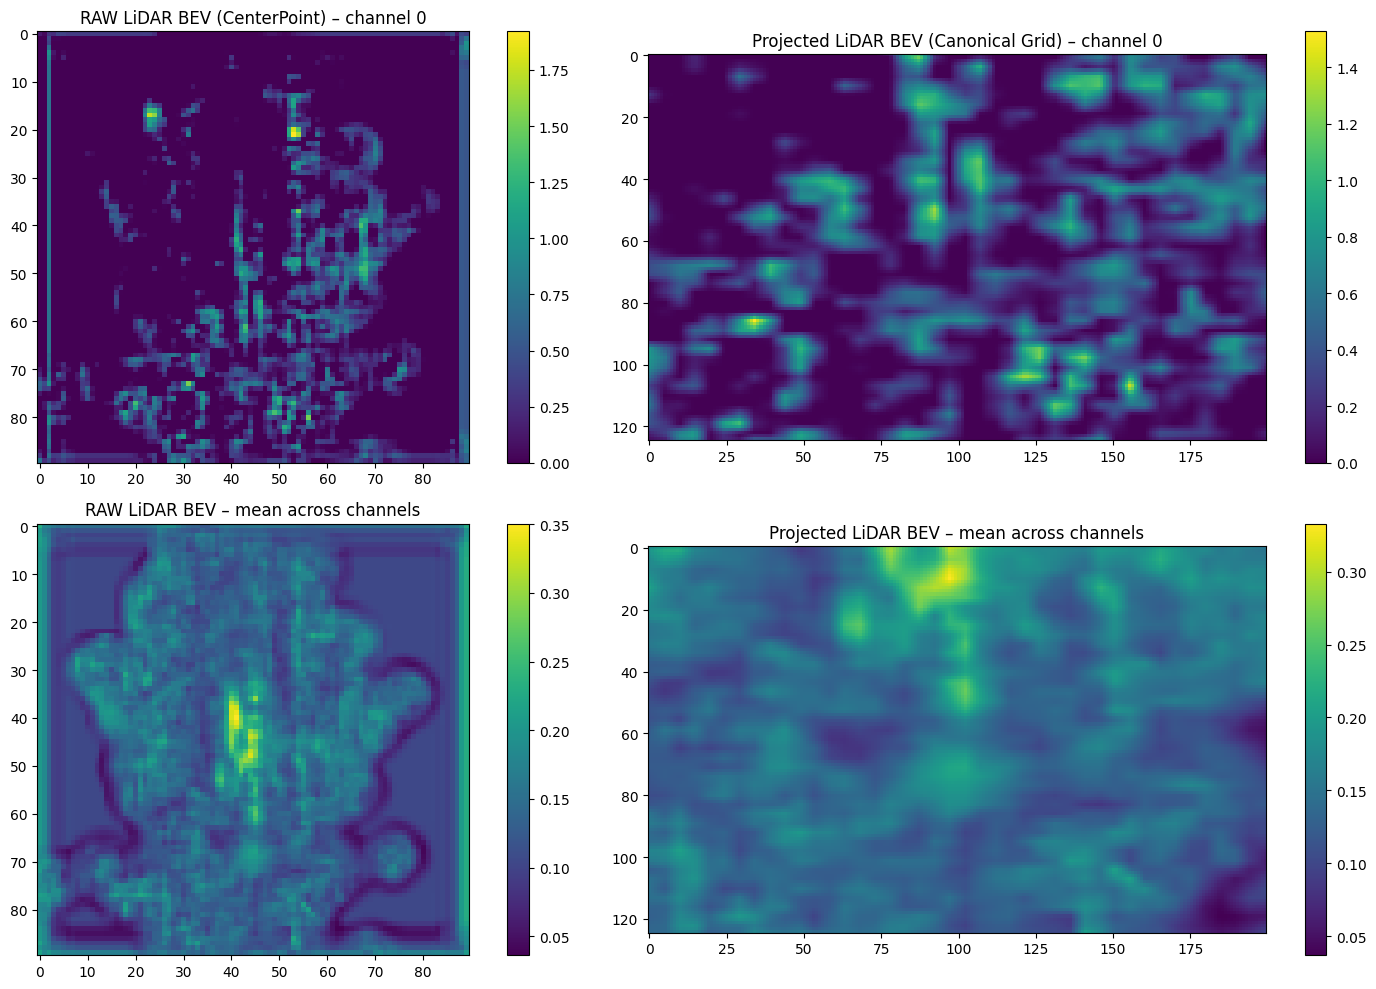

In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# ----------------------------------------------------
# Get the ONLY sample
# ----------------------------------------------------
sample = dataset[0]
token = sample["image_id"]

print("Token =", token)

# ----------------------------------------------------
# Load BEFORE (raw LiDAR BEV from CenterPoint)
# ----------------------------------------------------
lidar_raw_path = os.path.join(lidar_dir, f"{token}.pt")
lidar_raw_blob = torch.load(lidar_raw_path, map_location="cpu")

lidar_raw = lidar_raw_blob["feat"].float()
if lidar_raw.ndim == 3:
    lidar_raw = lidar_raw.unsqueeze(0)   # shape: [1, C, H_raw, W_raw]

# ----------------------------------------------------
# AFTER (canonical BEV from your projection)
# ----------------------------------------------------
lidar_bev = sample["lidar_bev"].float()
if lidar_bev.ndim == 3:
    lidar_bev = lidar_bev.unsqueeze(0)   # shape: [1, C, 125, 200]

# ----------------------------------------------------
# Pick a channel to visualize
# ----------------------------------------------------
ch = 0
raw_ch  = lidar_raw[0, ch].numpy()
bev_ch  = lidar_bev[0, ch].numpy()

raw_mean = lidar_raw[0].mean(0).numpy()
bev_mean = lidar_bev[0].mean(0).numpy()

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.title("RAW LiDAR BEV (CenterPoint) – channel 0")
plt.imshow(raw_ch, cmap='viridis')
plt.colorbar()

plt.subplot(2, 2, 2)
plt.title("Projected LiDAR BEV (Canonical Grid) – channel 0")
plt.imshow(bev_ch, cmap='viridis')
plt.colorbar()

plt.subplot(2, 2, 3)
plt.title("RAW LiDAR BEV – mean across channels")
plt.imshow(raw_mean, cmap='viridis')
plt.colorbar()

plt.subplot(2, 2, 4)
plt.title("Projected LiDAR BEV – mean across channels")
plt.imshow(bev_mean, cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()


In [18]:
import torch
import numpy as np
import torch.nn.functional as F
import os
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

class TorchLidarMaskedBEVDataset:
    """
    Loads raw LiDAR BEV, masks to camera FOV, then projects the masked LiDAR
    into the canonical BEV grid (same as your current BEV projection).
    """
    def __init__(self, tokens, lidar_root, camera_root,
                 pc_range, bev_spec, bev_resolution):
        self.tokens = tokens
        self.lidar_root = lidar_root
        self.camera_root = camera_root
        self.pc_range = pc_range
        self.bev_spec = bev_spec
        self.bev_resolution = bev_resolution   # (dx, dy) for masking

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):

        token = self.tokens[idx]

        # ------------------------------------------------------------
        # 1) LOAD RAW LIDAR BEV FEATURE
        # ------------------------------------------------------------
        lidar_path = os.path.join(self.lidar_root, f"{token}.pt")
        lidar_blob = torch.load(lidar_path, map_location="cpu")
        lidar_raw = lidar_blob["feat"].squeeze(0)   # [C, H_raw, W_raw]

        # ------------------------------------------------------------
        # 2) LOAD CAMERA CALIBRATION (lidar2img, img_shape)
        # ------------------------------------------------------------
        cam_path = os.path.join(self.camera_root, f"{token}.pt")
        camera_data = torch.load(cam_path, map_location="cpu")
        lidar2img = camera_data["lidar2img"]
        img_shape = tuple(camera_data["img_shape"][0])[:2]  # (H, W)

        # ------------------------------------------------------------
        # 3) MASK LIDAR USING YOUR OLD crop FUNCTION
        # ------------------------------------------------------------
        lidar_masked = crop_lidar_bev_to_camera_fov(
            lidar_raw, lidar2img, img_shape,
            self.bev_resolution, self.pc_range
        )  # output: [C, H_raw, W_raw]

        # ------------------------------------------------------------
        # 4) PROJECT MASKED LIDAR INTO CANONICAL BEV GRID
        # (same exact code as your new BEV projection)
        # ------------------------------------------------------------
        x_min_l, y_min_l, _, x_max_l, y_max_l, _ = self.pc_range

        H_cam = self.bev_spec.H
        W_cam = self.bev_spec.W

        xs = self.bev_spec.x_min + (torch.arange(H_cam) + 0.5) * self.bev_spec.cell_x
        ys = self.bev_spec.y_min + (torch.arange(W_cam) + 0.5) * self.bev_spec.cell_y
        Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

        grid_x = 2.0 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1.0
        grid_y = 2.0 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1.0

        grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

        lidar_masked = lidar_masked.unsqueeze(0)  # [1,C,H_raw,W_raw]
        lidar_bev_out = F.grid_sample(
            lidar_masked, grid,
            mode='bilinear',
            padding_mode='zeros',
            align_corners=True
        ).squeeze(0)  # [C, H_cam, W_cam]

        return {
            "lidar_raw": lidar_raw,          # BEFORE any masking
            "lidar_masked": lidar_masked[0], # AFTER FOV masking
            "lidar_bev": lidar_bev_out,      # masked → canonical grid
            "image_id": token,
        }


ModuleNotFoundError: No module named 'lavis'

In [8]:
import matplotlib.pyplot as plt

def visualize_lidar_pipeline(sample):

    raw = sample["lidar_raw"]
    masked = sample["lidar_masked"]
    bev = sample["lidar_bev"]

    raw_mean = raw.mean(0).numpy()
    masked_mean = masked.mean(0).numpy()
    bev_mean = bev.mean(0).numpy()

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.title("RAW LiDAR BEV (CenterPoint)")
    plt.imshow(raw_mean, cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title("LIDAR Masked to CAM_FRONT FOV")
    plt.imshow(masked_mean, cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title("Masked → Canonical BEV (Projected)")
    plt.imshow(bev_mean, cmap='viridis')
    plt.colorbar()

    plt.tight_layout()
    plt.show()


In [9]:
camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/testing/features_benign/CAM_FRONT/fpn"
lidar_dir  = "/home/draiman/Desktop/Datasets_nuscenes/testing/features_benign/lidar"
metadata_csv = "/home/draiman/Desktop/Datasets_nuscenes/nusc_pseudo_test_metadata.csv"

tokens = get_matched_tokens(camera_dir, lidar_dir, fpn_level=0)

masked_ds = TorchLidarMaskedBEVDataset(
    tokens=tokens,
    lidar_root=lidar_dir,
    camera_root=camera_dir,
    pc_range=[-54, -54, -5, 54, 54, 3],
    bev_spec=bev_spec,
    bev_resolution=(1.14, 1.14)
)

sample = masked_ds[0]
visualize_lidar_pipeline(sample)


FileNotFoundError: [Errno 2] No such file or directory: '/home/draiman/Desktop/Datasets_nuscenes/testing/features_benign/CAM_FRONT/fpn/5937faeeeb7d40b4903a441b0b95b204.pt'

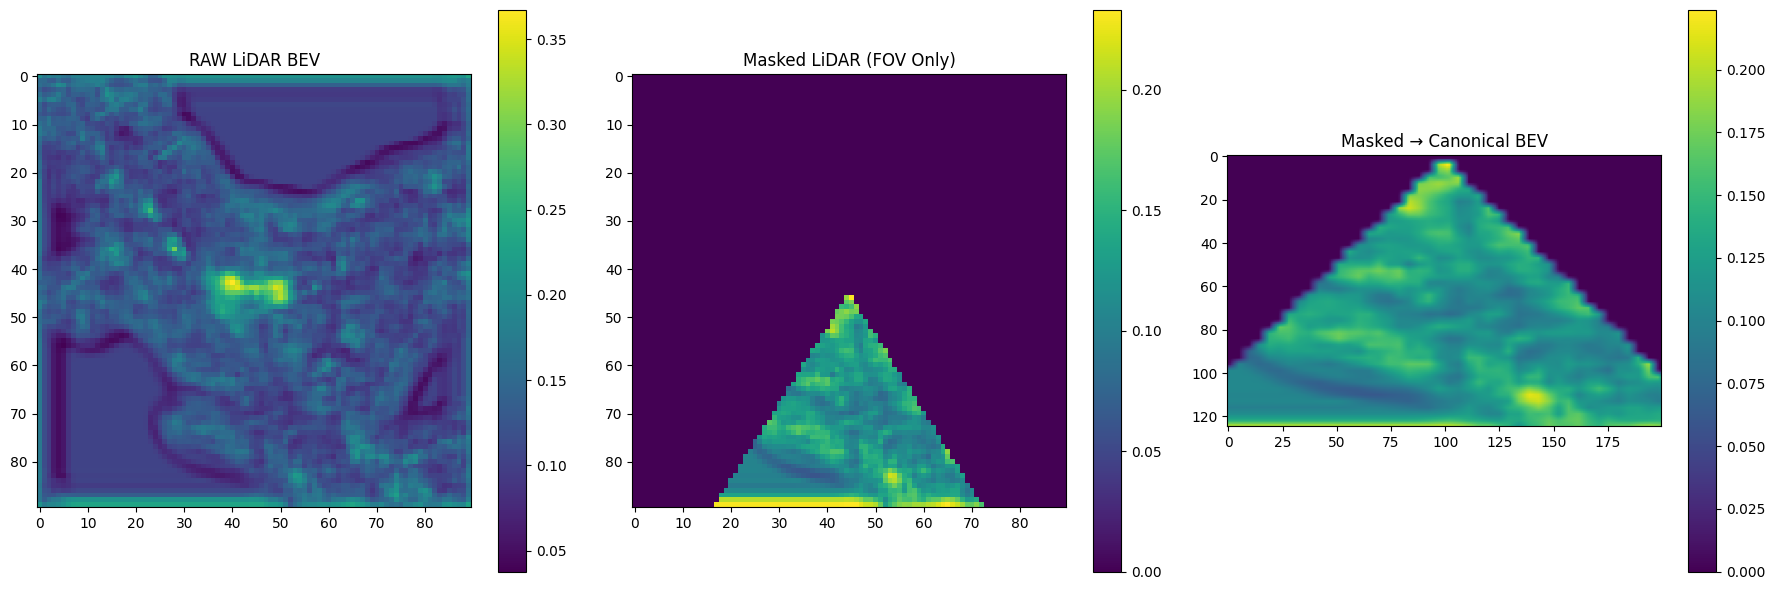

In [11]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

# lidar_file = f"/home/draiman/Desktop/Datasets_nuscenes/lidar/{token}.pt"
lidar_file_b = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_1.pt"
cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
lidar_raw = torch.load(lidar_file_b)["feat"].squeeze(0)   # [C, H, W]

# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)

lidar_raw = torch.rot90(lidar_raw, k=-1, dims=[1, 2])

masked_lidar = crop_lidar_bev_to_camera_fov(
    lidar_raw,
    lidar2img,
    img_shape,
    bev_resolution=(1.14, 1.14),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_batch = masked_lidar.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical = F.grid_sample(
    lidar_masked_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)




plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw.mean(0), cmap='viridis')
# plt.imshow(raw_rot, cmap='viridis')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("Masked LiDAR (FOV Only)")
plt.imshow(masked_lidar.mean(0), cmap='viridis')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("Masked → Canonical BEV")
plt.imshow(lidar_bev_canonical.mean(0), cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()



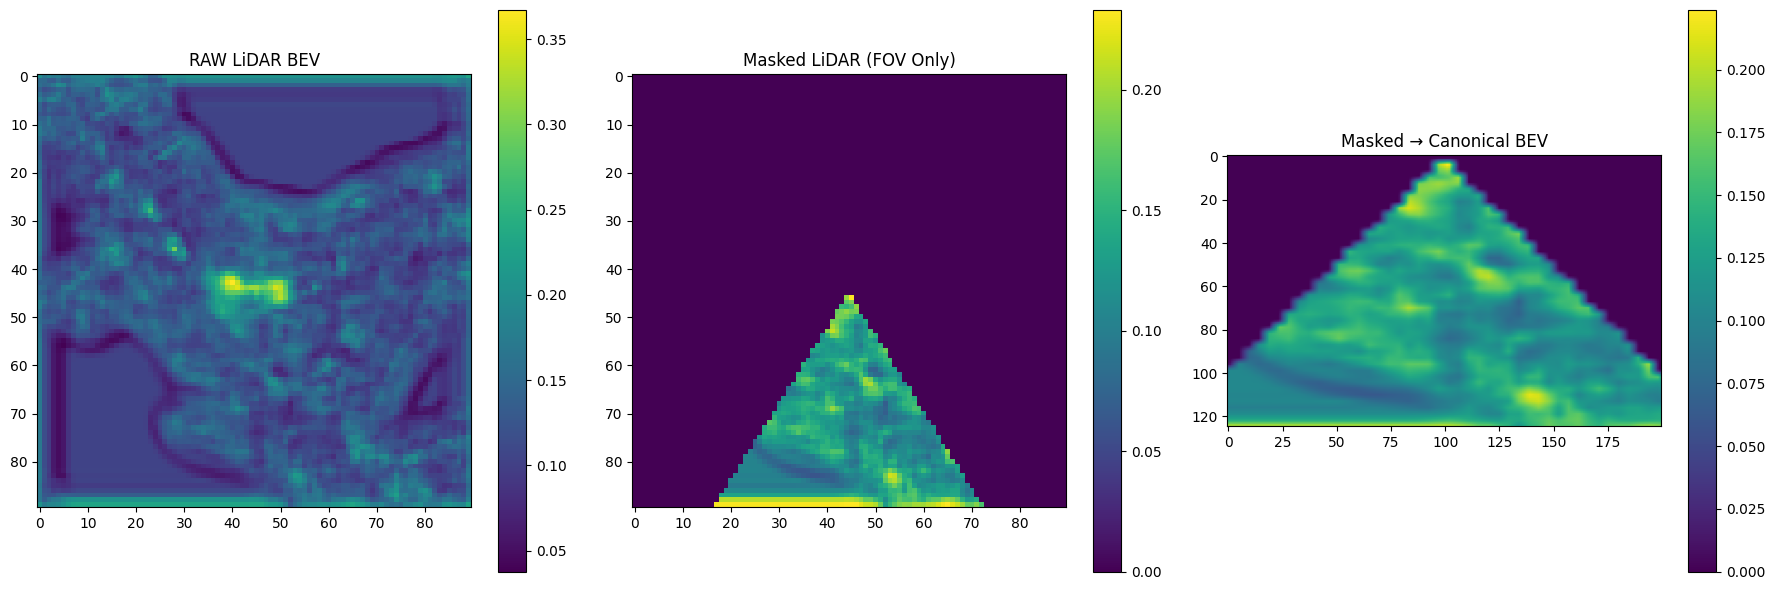

In [12]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

# lidar_file = f"/home/draiman/Desktop/Datasets_nuscenes/lidar/{token}.pt"
lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_synth.pt"
cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
lidar_raw_synth = torch.load(lidar_file)["feat"].squeeze(0)   # [C, H, W]

# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)



lidar_raw_synth = torch.rot90(lidar_raw_synth, k=-1, dims=[1, 2])


masked_lidar = crop_lidar_bev_to_camera_fov(
    lidar_raw_synth,
    lidar2img,
    img_shape,
    bev_resolution=(1.14, 1.14),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_batch = masked_lidar.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical = F.grid_sample(
    lidar_masked_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)





plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_synth.mean(0), cmap='viridis')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("Masked LiDAR (FOV Only)")
plt.imshow(masked_lidar.mean(0), cmap='viridis')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("Masked → Canonical BEV")
plt.imshow(lidar_bev_canonical.mean(0), cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()



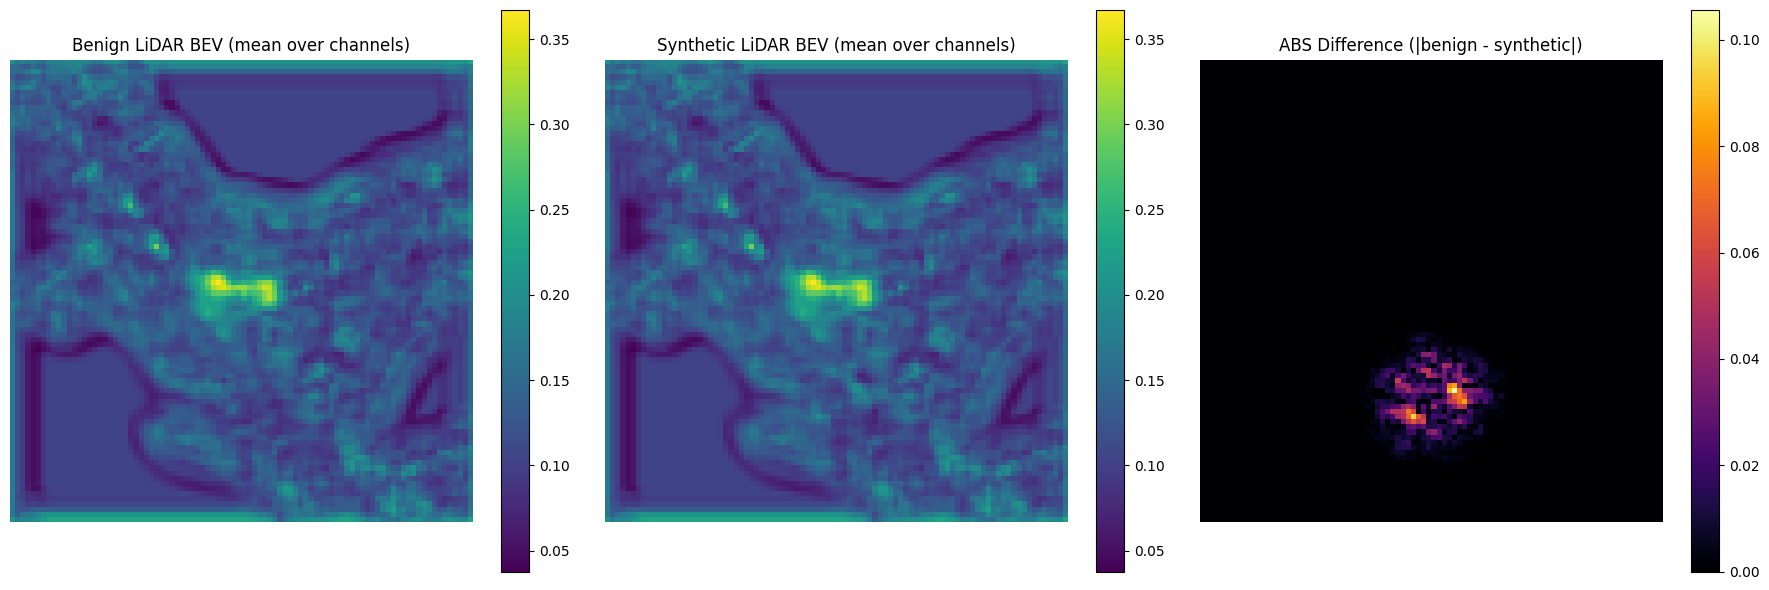

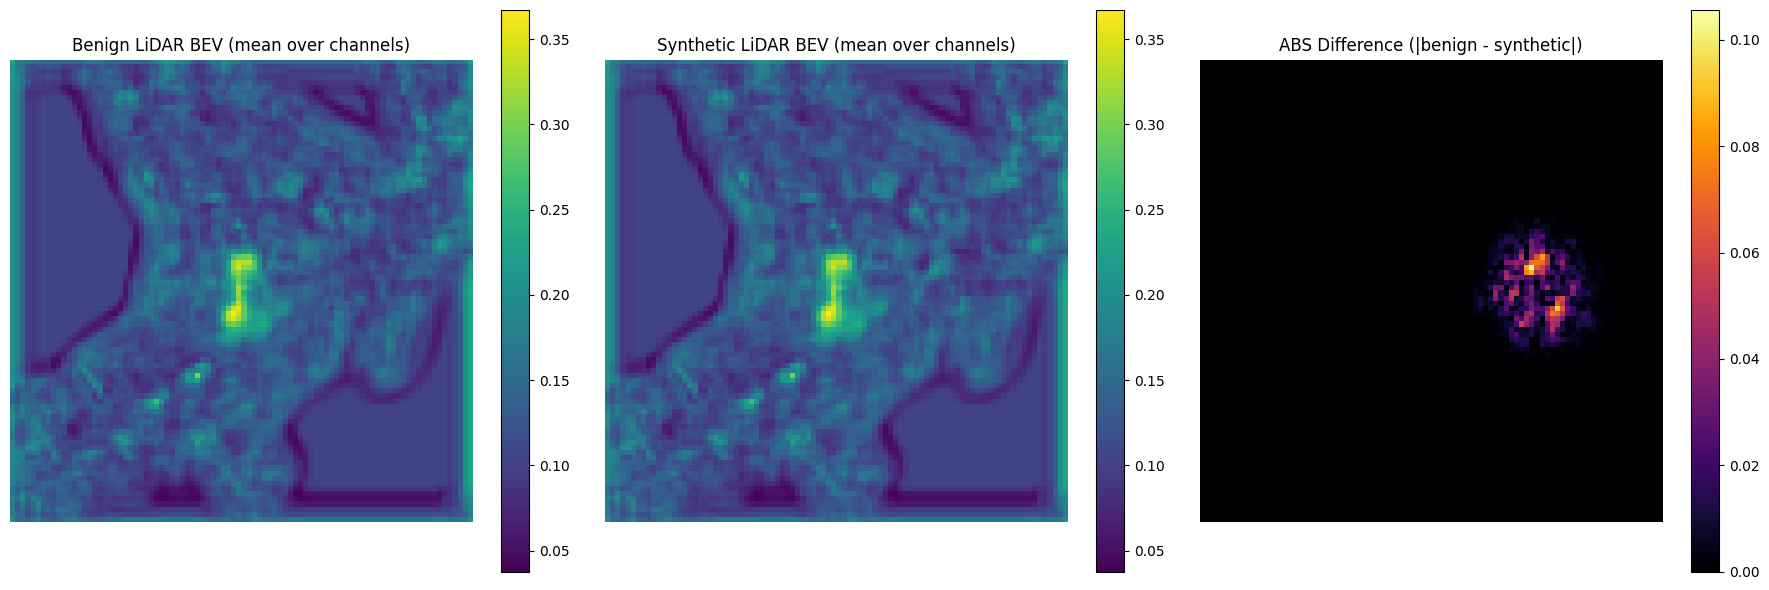

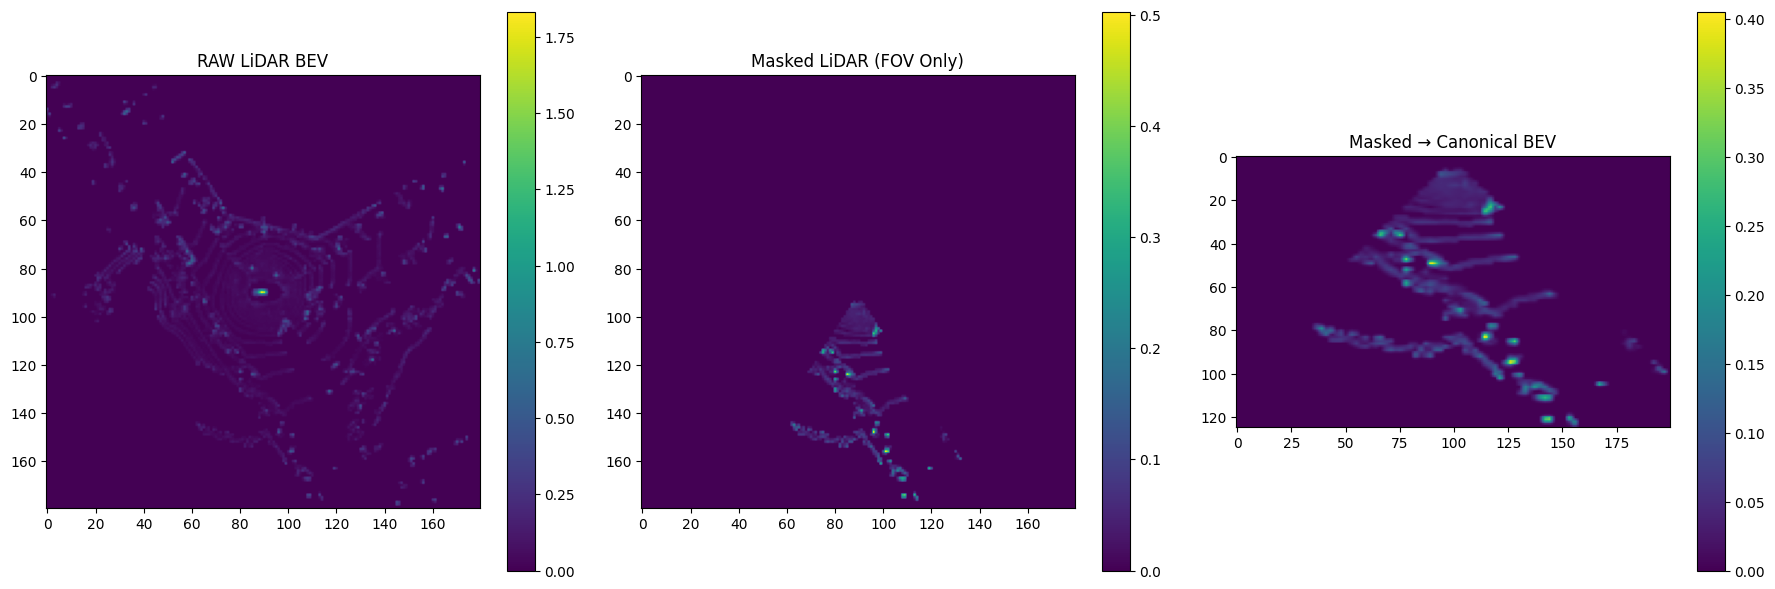

In [34]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

# lidar_file = f"/home/draiman/Desktop/Datasets_nuscenes/lidar/{token}.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_synth.pt"
lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/benign_early_layers.pt"

cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
lidar_raw = torch.load(lidar_file)["spatial"].squeeze(0)   # [C, H, W]

# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)



lidar_raw = torch.rot90(lidar_raw, k=-1, dims=[1, 2])


masked_lidar = crop_lidar_bev_to_camera_fov(
    lidar_raw,
    lidar2img,
    img_shape,
    # bev_resolution=(1.14, 1.14),
    bev_resolution = (0.57, 0.57),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_batch = masked_lidar.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical = F.grid_sample(
    lidar_masked_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)





plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw.mean(0), cmap='viridis')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("Masked LiDAR (FOV Only)")
plt.imshow(masked_lidar.mean(0), cmap='viridis')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("Masked → Canonical BEV")
plt.imshow(lidar_bev_canonical.mean(0), cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()



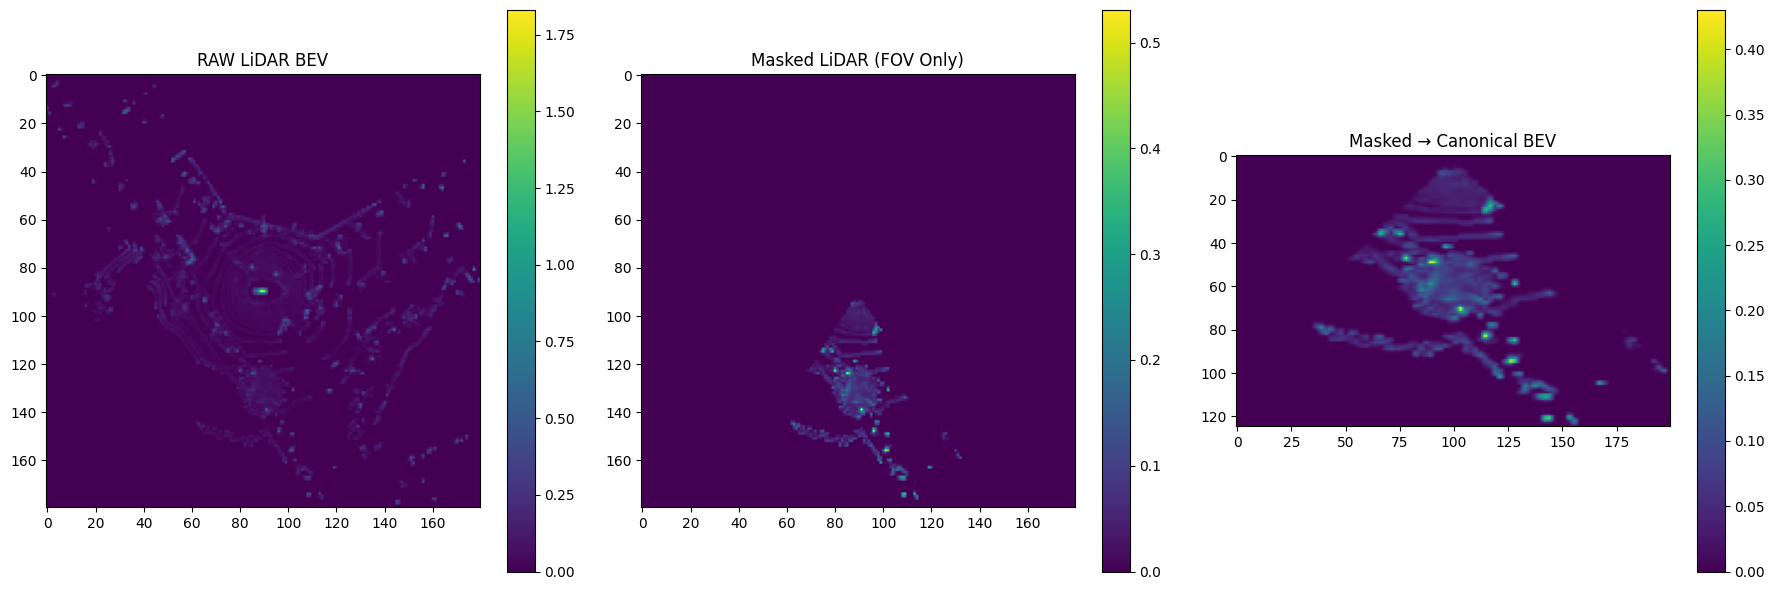

In [ ]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

# lidar_file = f"/home/draiman/Desktop/Datasets_nuscenes/lidar/{token}.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_synth.pt"
lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_early_layers.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_50pts_early_layers.pt"

cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
lidar_raw_synth = torch.load(lidar_file)["spatial"].squeeze(0)   # [C, H, W]


# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)



lidar_raw_synth = torch.rot90(lidar_raw_synth, k=-1, dims=[1, 2])


masked_lidar = crop_lidar_bev_to_camera_fov(
    lidar_raw_synth,
    lidar2img,
    img_shape,
    # bev_resolution=(1.14, 1.14),
    bev_resolution = (0.57, 0.57),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_batch = masked_lidar.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical = F.grid_sample(
    lidar_masked_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)





plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_synth.mean(0), cmap='viridis')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("Masked LiDAR (FOV Only)")
plt.imshow(masked_lidar.mean(0), cmap='viridis')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("Masked → Canonical BEV")
plt.imshow(lidar_bev_canonical.mean(0), cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()



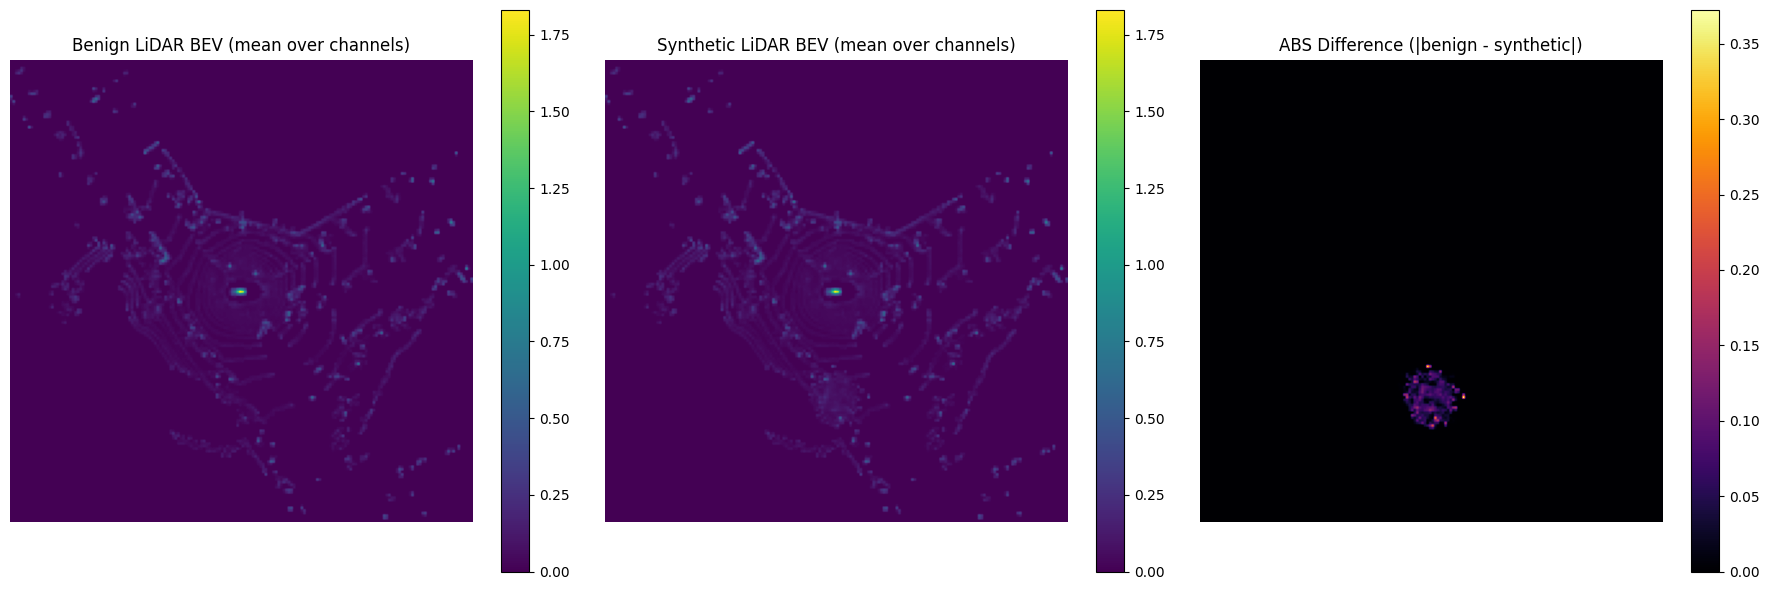

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# lidar_raw        → benign   LiDAR BEV   [C,H,W]
# lidar_raw_synth  → synthetic LiDAR BEV  [C,H,W]
# ----------------------------------------------------------

raw_mean   = lidar_raw.mean(0).numpy()
synth_mean = lidar_raw_synth.mean(0).numpy()

# Absolute difference heatmap
diff = np.abs(raw_mean - synth_mean)

plt.figure(figsize=(18, 6))

# ------------ BENIGN -----------------
plt.subplot(1, 3, 1)
plt.title("Benign LiDAR BEV (mean over channels)")
plt.imshow(raw_mean, cmap="viridis")
plt.colorbar()
plt.axis('off')

# ------------ SYNTHETIC --------------
plt.subplot(1, 3, 2)
plt.title("Synthetic LiDAR BEV (mean over channels)")
plt.imshow(synth_mean, cmap="viridis")
plt.colorbar()
plt.axis('off')

# ------------ DIFFERENCE -------------
plt.subplot(1, 3, 3)
plt.title("ABS Difference (|benign - synthetic|)")
plt.imshow(diff, cmap="inferno")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()


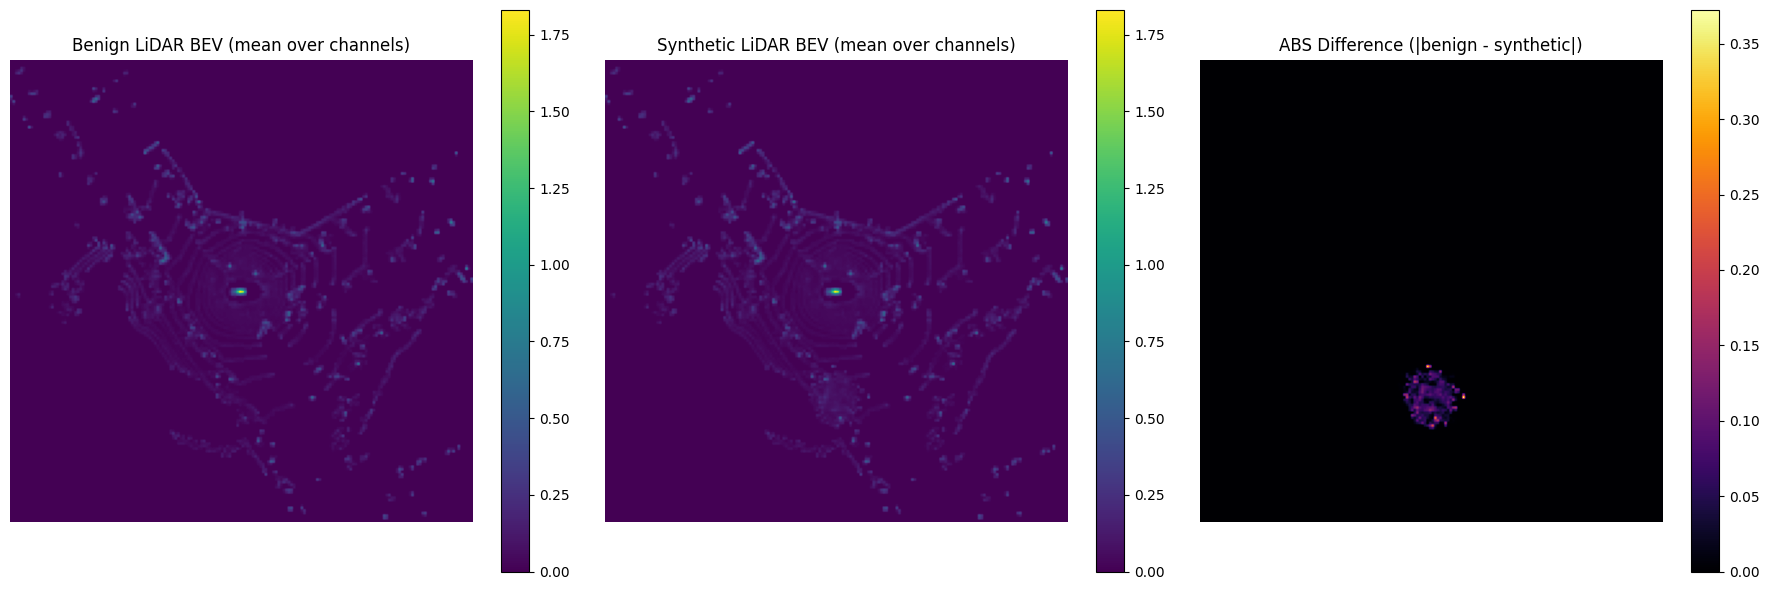

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# lidar_raw        → benign   LiDAR BEV   [C,H,W]
# lidar_raw_synth  → synthetic LiDAR BEV  [C,H,W]
# ----------------------------------------------------------

raw_mean   = lidar_raw.mean(0).numpy()
synth_mean = lidar_raw_synth.mean(0).numpy()

# Absolute difference heatmap
diff = np.abs(raw_mean - synth_mean)

plt.figure(figsize=(18, 6))

# ------------ BENIGN -----------------
plt.subplot(1, 3, 1)
plt.title("Benign LiDAR BEV (mean over channels)")
plt.imshow(raw_mean, cmap="viridis")
plt.colorbar()
plt.axis('off')

# ------------ SYNTHETIC --------------
plt.subplot(1, 3, 2)
plt.title("Synthetic LiDAR BEV (mean over channels)")
plt.imshow(synth_mean, cmap="viridis")
plt.colorbar()
plt.axis('off')

# ------------ DIFFERENCE -------------
plt.subplot(1, 3, 3)
plt.title("ABS Difference (|benign - synthetic|)")
plt.imshow(diff, cmap="inferno")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()


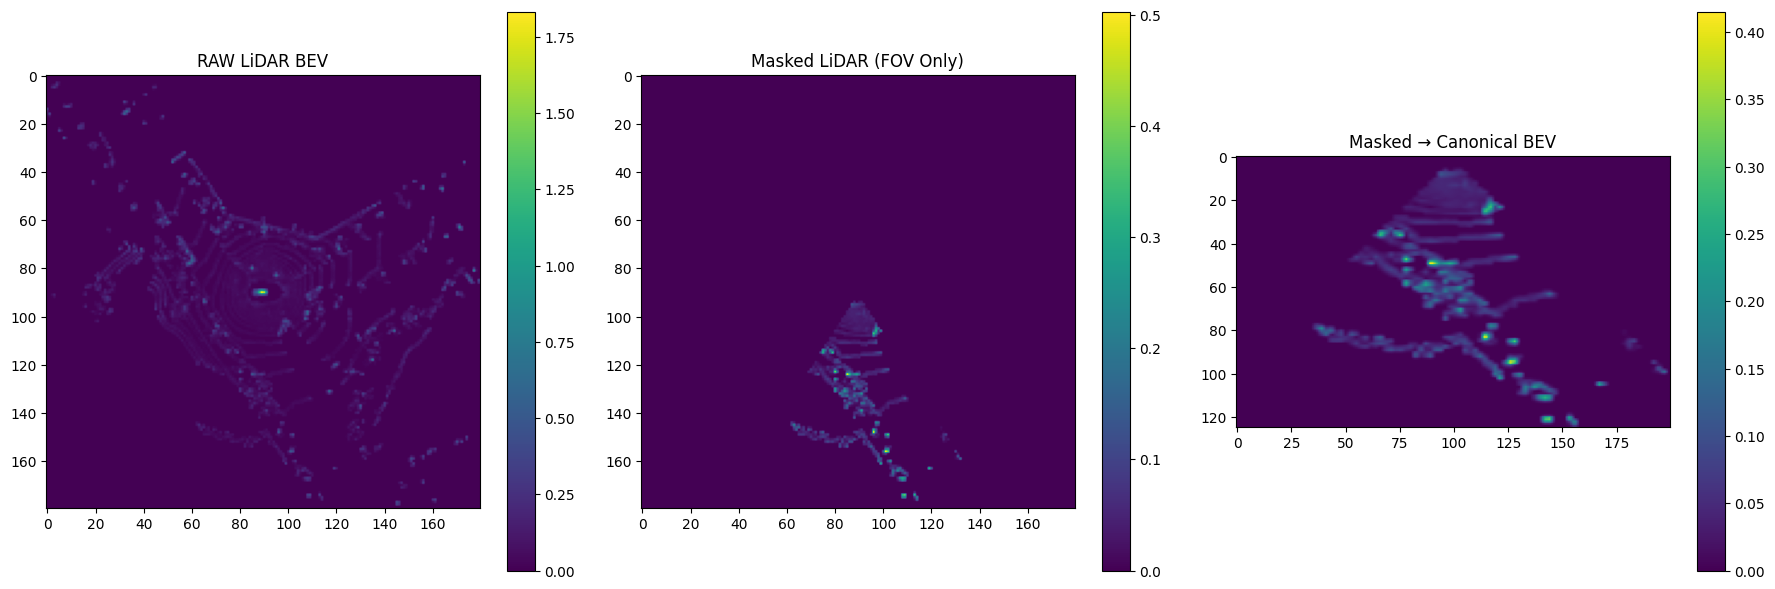

In [41]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

# lidar_file = f"/home/draiman/Desktop/Datasets_nuscenes/lidar/{token}.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_synth.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_early_layers.pt"
lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_50pts_early_layers.pt"

cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
lidar_raw_synth = torch.load(lidar_file)["spatial"].squeeze(0)   # [C, H, W]


# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)



lidar_raw_synth = torch.rot90(lidar_raw_synth, k=-1, dims=[1, 2])


masked_lidar = crop_lidar_bev_to_camera_fov(
    lidar_raw_synth,
    lidar2img,
    img_shape,
    # bev_resolution=(1.14, 1.14),
    bev_resolution = (0.57, 0.57),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_batch = masked_lidar.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical = F.grid_sample(
    lidar_masked_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)





plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_synth.mean(0), cmap='viridis')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("Masked LiDAR (FOV Only)")
plt.imshow(masked_lidar.mean(0), cmap='viridis')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("Masked → Canonical BEV")
plt.imshow(lidar_bev_canonical.mean(0), cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()



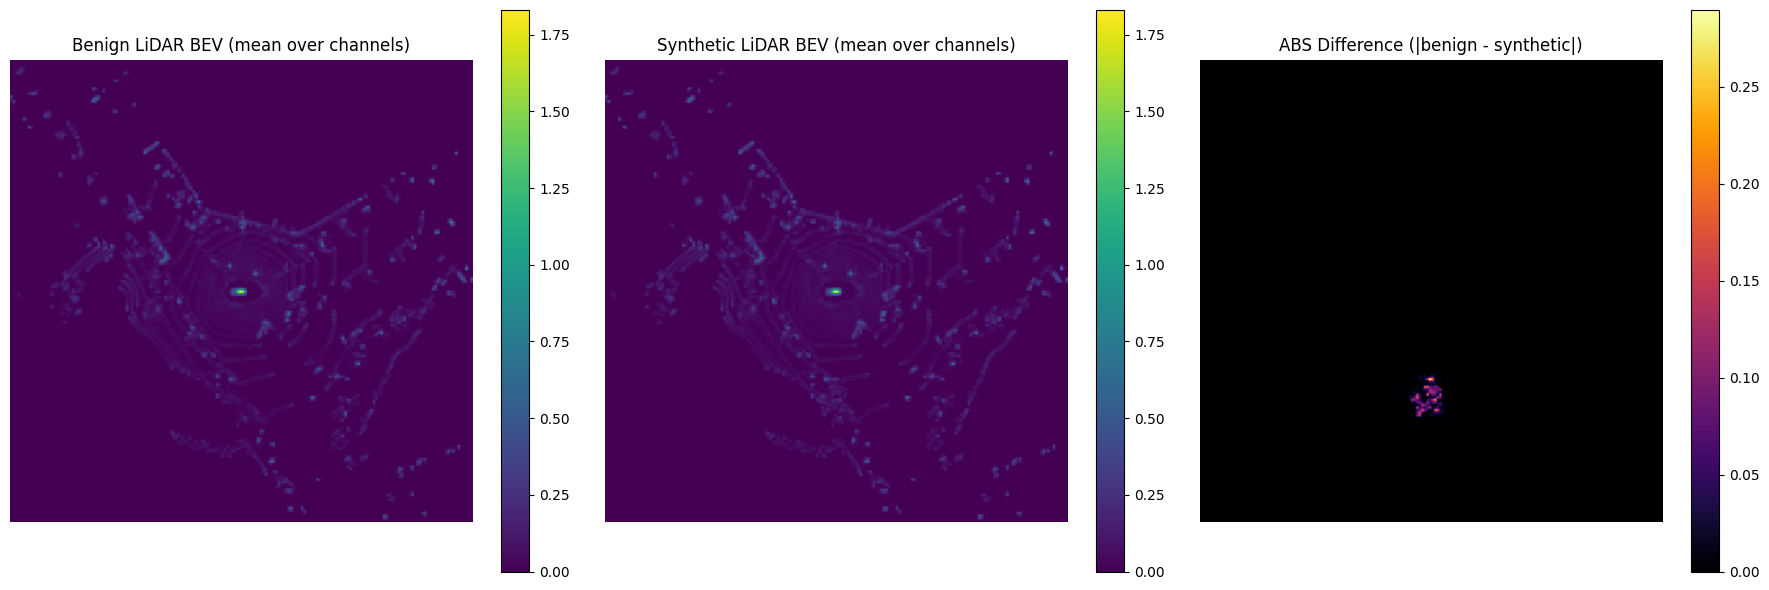

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# lidar_raw        → benign   LiDAR BEV   [C,H,W]
# lidar_raw_synth  → synthetic LiDAR BEV  [C,H,W]
# ----------------------------------------------------------

raw_mean   = lidar_raw.mean(0).numpy()
synth_mean = lidar_raw_synth.mean(0).numpy()

# Absolute difference heatmap
diff = np.abs(raw_mean - synth_mean)

plt.figure(figsize=(18, 6))

# ------------ BENIGN -----------------
plt.subplot(1, 3, 1)
plt.title("Benign LiDAR BEV (mean over channels)")
plt.imshow(raw_mean, cmap="viridis")
plt.colorbar()
plt.axis('off')

# ------------ SYNTHETIC --------------
plt.subplot(1, 3, 2)
plt.title("Synthetic LiDAR BEV (mean over channels)")
plt.imshow(synth_mean, cmap="viridis")
plt.colorbar()
plt.axis('off')

# ------------ DIFFERENCE -------------
plt.subplot(1, 3, 3)
plt.title("ABS Difference (|benign - synthetic|)")
plt.imshow(diff, cmap="inferno")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()


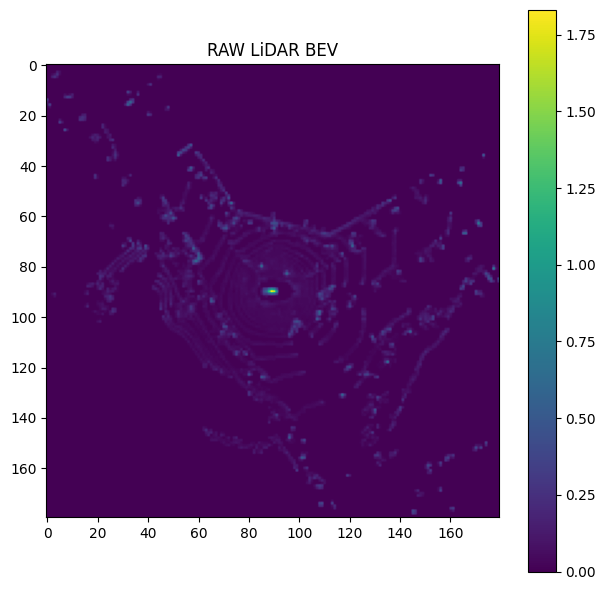

In [8]:
import sys
sys.path.append("/home/draiman/Desktop/")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

# lidar_file = f"/home/draiman/Desktop/Datasets_nuscenes/lidar/{token}.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_synth.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_early_layers.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_50pts_early_layers.pt"
lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers_frustum_attacked_sample/masked_lidar_early_layers.pt"


cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
lidar_raw_masked = torch.load(lidar_file)["spatial"].squeeze(0)   # [C, H, W]


# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)



lidar_raw_masked = torch.rot90(lidar_raw_masked, k=-1, dims=[1, 2])


masked_lidar = crop_lidar_bev_to_camera_fov(
    lidar_raw_masked,
    lidar2img,
    img_shape,
    # bev_resolution=(1.14, 1.14),
    bev_resolution = (0.57, 0.57),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_batch = masked_lidar.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical = F.grid_sample(
    lidar_masked_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)





plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_synth.mean(0), cmap='viridis')
plt.colorbar()

# plt.subplot(1, 3, 2)
# plt.title("Masked LiDAR (FOV Only)")
# plt.imshow(masked_lidar.mean(0), cmap='viridis')
# plt.colorbar()

# plt.subplot(1, 3, 3)
# plt.title("Masked → Canonical BEV")
# plt.imshow(lidar_bev_canonical.mean(0), cmap='viridis')
# plt.colorbar()

plt.tight_layout()
plt.show()



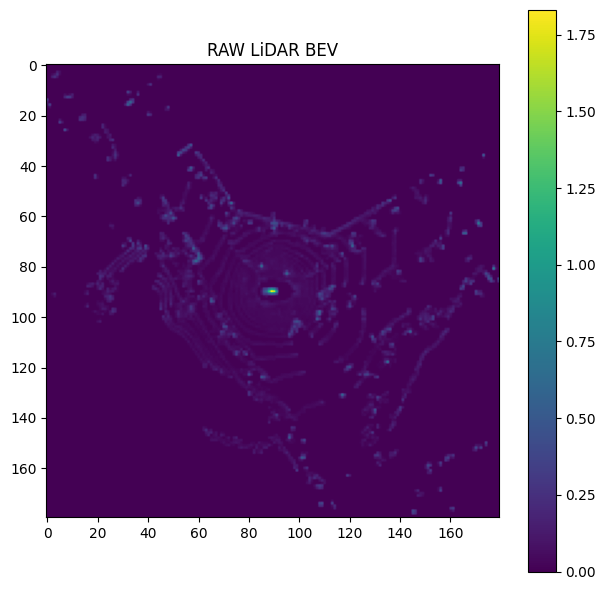

In [9]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

# lidar_file = f"/home/draiman/Desktop/Datasets_nuscenes/lidar/{token}.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_synth.pt"
lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/benign_early_layers.pt"

# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_early_layers.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_50pts_early_layers.pt"

cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
lidar_raw_synth = torch.load(lidar_file)["spatial"].squeeze(0)   # [C, H, W]


# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)



lidar_raw_synth = torch.rot90(lidar_raw_synth, k=-1, dims=[1, 2])


masked_lidar = crop_lidar_bev_to_camera_fov(
    lidar_raw_synth,
    lidar2img,
    img_shape,
    # bev_resolution=(1.14, 1.14),
    bev_resolution = (0.57, 0.57),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_batch = masked_lidar.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical = F.grid_sample(
    lidar_masked_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)





plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_synth.mean(0), cmap='viridis')
plt.colorbar()

# plt.subplot(1, 3, 2)
# plt.title("Masked LiDAR (FOV Only)")
# plt.imshow(masked_lidar.mean(0), cmap='viridis')
# plt.colorbar()

# plt.subplot(1, 3, 3)
# plt.title("Masked → Canonical BEV")
# plt.imshow(lidar_bev_canonical.mean(0), cmap='viridis')
# plt.colorbar()

plt.tight_layout()
plt.show()



In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# lidar_raw        → benign   LiDAR BEV   [C,H,W]
# lidar_raw_synth  → synthetic LiDAR BEV  [C,H,W]
# ----------------------------------------------------------

raw_mean   = lidar_raw.mean(0).numpy()
synth_mean = lidar_raw_synth.mean(0).numpy()

# Absolute difference heatmap
diff = np.abs(raw_mean - lidar_raw_synth)

plt.figure(figsize=(18, 6))

# ------------ BENIGN -----------------
plt.subplot(1, 3, 1)
plt.title("Benign LiDAR BEV (mean over channels)")
plt.imshow(raw_mean, cmap="viridis")
plt.colorbar()
plt.axis('off')

# ------------ SYNTHETIC --------------
plt.subplot(1, 3, 2)
plt.title("Synthetic LiDAR BEV (mean over channels)")
plt.imshow(synth_mean, cmap="viridis")
plt.colorbar()
plt.axis('off')

# ------------ DIFFERENCE -------------
plt.subplot(1, 3, 3)
plt.title("ABS Difference (|benign - synthetic|)")
plt.imshow(diff, cmap="inferno")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()


NameError: name 'lidar_raw' is not defined

dict_keys(['voxel_feats', 'spatial', 'bev_c1', 'bev_c2'])
['voxel_feats', 'spatial', 'bev_c1', 'bev_c2']
Processing spatial


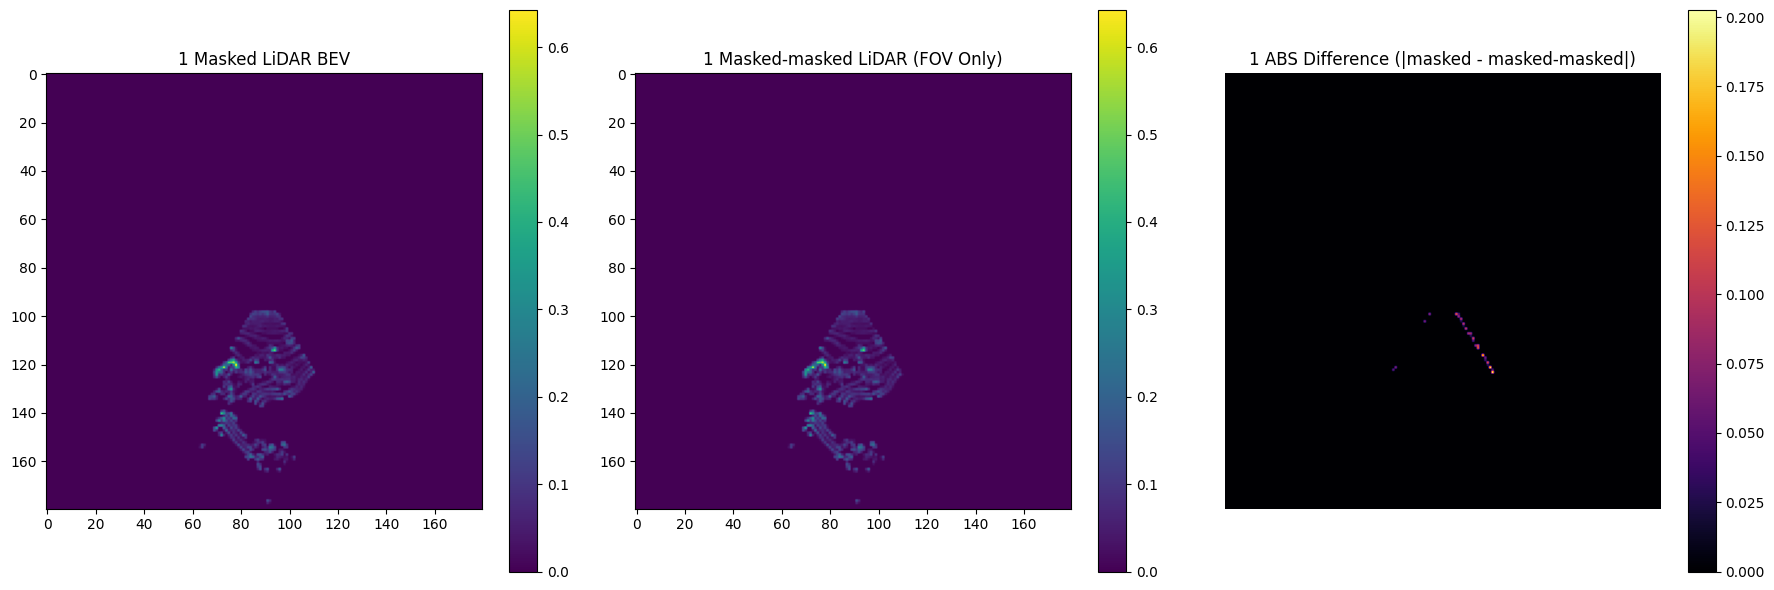

Processing bev_c1


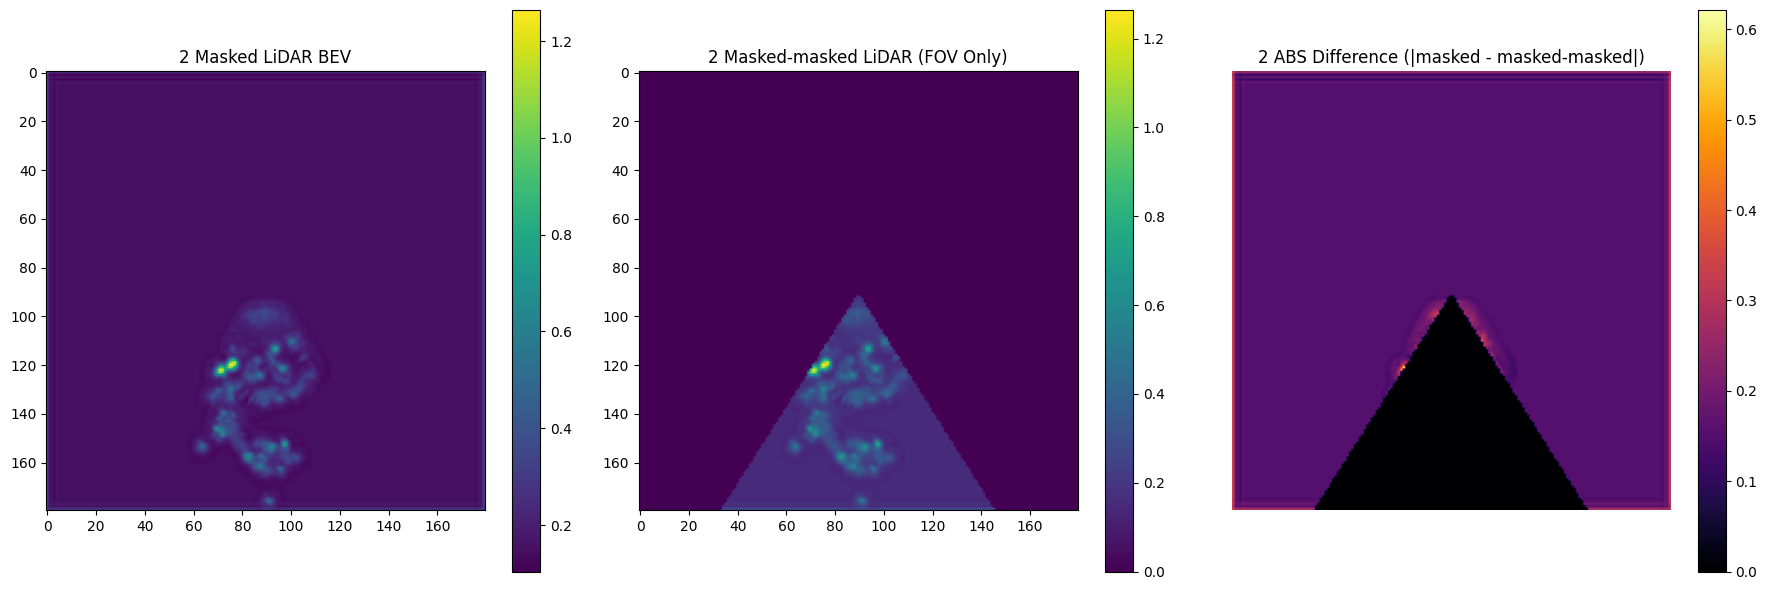

Processing bev_c2


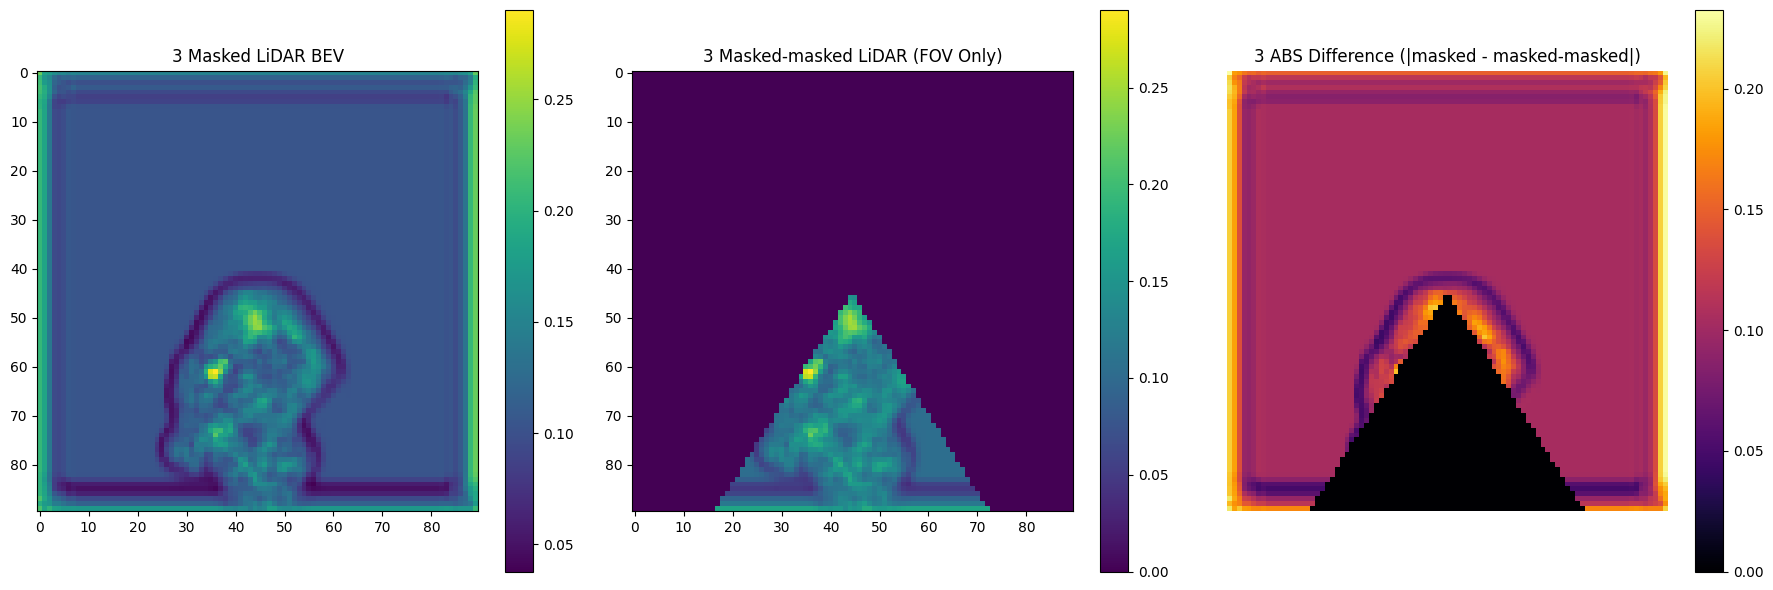

In [75]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers_masked_full/masked_lidar_early_layers.pt"
# lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/benign_early_layers.pt"

cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"



# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)




class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

# masked_lidar = torch.rot90(masked_lidar, k=-1, dims=[1, 2])

masked_lidar_o = torch.load(lidar_file)
print(masked_lidar_o.keys())
keys = list(masked_lidar_o.keys())
# keys = np.array(keys)
print(keys)
for i in range(1, len(keys)):  # start from index 1
    key = keys[i]
    print(f"Processing {key}")

    masked_lidar = masked_lidar_o[key].squeeze(0)
    # masked_lidar = torch.load(lidar_file)[f"'{keys[i]}'"].squeeze(0)   # [C, H, W]
    # masked_lidar = masked_lidar_o[f"{keys[i]}"].squeeze(0)
    masked_masked_lidar = crop_lidar_bev_to_camera_fov(
        masked_lidar,
        lidar2img,
        img_shape,
        # bev_resolution=(1.14, 1.14),
        bev_resolution = (0.57, 0.57),
        pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
    )

    bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


    # Lidar masked: [C, H_raw, W_raw] → add batch
    lidar_masked_batch = masked_masked_lidar.unsqueeze(0)

    x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

    xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
    ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
    Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

    grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
    grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
    grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

    lidar_bev_canonical = F.grid_sample(
        lidar_masked_batch, grid,
        mode='bilinear', padding_mode='zeros', align_corners=True
    ).squeeze(0)



    masked_lidar_mean = masked_lidar.mean(0).numpy()
    masked_masked_lidar_mean = masked_masked_lidar.mean(0).numpy()


    # Absolute difference heatmap
    diff = np.abs(masked_masked_lidar_mean - masked_lidar_mean)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.title(f"{i} Masked LiDAR BEV")
    plt.imshow(masked_lidar.mean(0), cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title(f"{i} Masked-masked LiDAR (FOV Only)")
    plt.imshow(masked_masked_lidar.mean(0), cmap='viridis')
    plt.colorbar()

    # ------------ DIFFERENCE -------------
    plt.subplot(1, 3, 3)
    plt.title( f"{i} ABS Difference (|masked - masked-masked|)")
    plt.imshow(diff, cmap="inferno")
    plt.colorbar()
    plt.axis('off')

    plt.tight_layout()
    plt.show()



In [1]:
# masked_lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers_masked_full/masked_lidar_early_layers.pt"
masked_lidar_file = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers_masked_full/full_lidar_early_layers.pt"



# Load LiDAR BEV
ss = torch.load(lidar_file)
print("lidar_file", ss.keys())

lidar_raw_masked = torch.load(lidar_file)["spatial"].squeeze(0)   # [C, H, W]


# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)



# lidar_raw_masked = torch.rot90(lidar_raw_masked, k=-1, dims=[1, 2])



plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_masked.mean(0), cmap='viridis')
plt.colorbar()




NameError: name 'lidar2img_nusc' is not defined

dict_keys(['voxel_feats', 'spatial', 'bev_c1', 'bev_c2'])
['voxel_feats', 'spatial', 'bev_c1', 'bev_c2']
Processing spatial


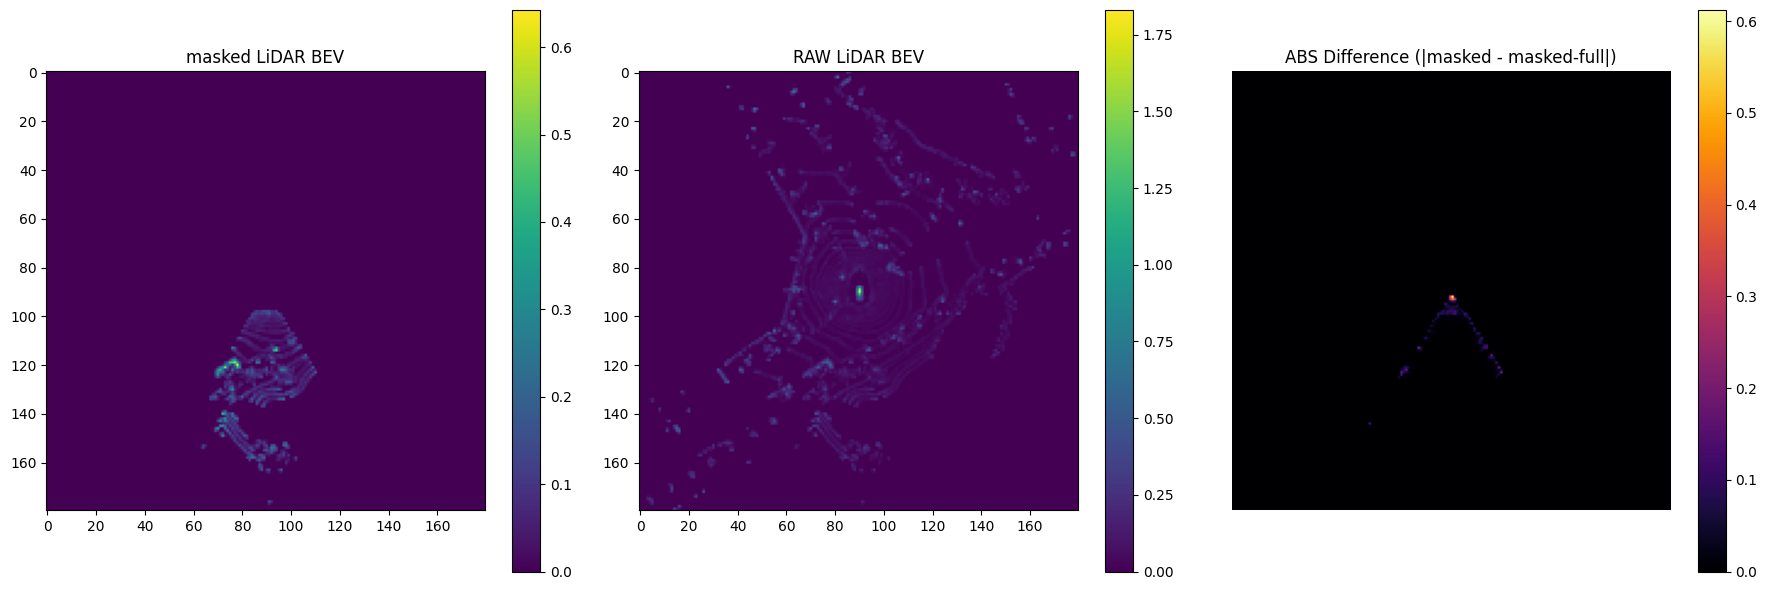

<Figure size 640x480 with 0 Axes>

Processing bev_c1


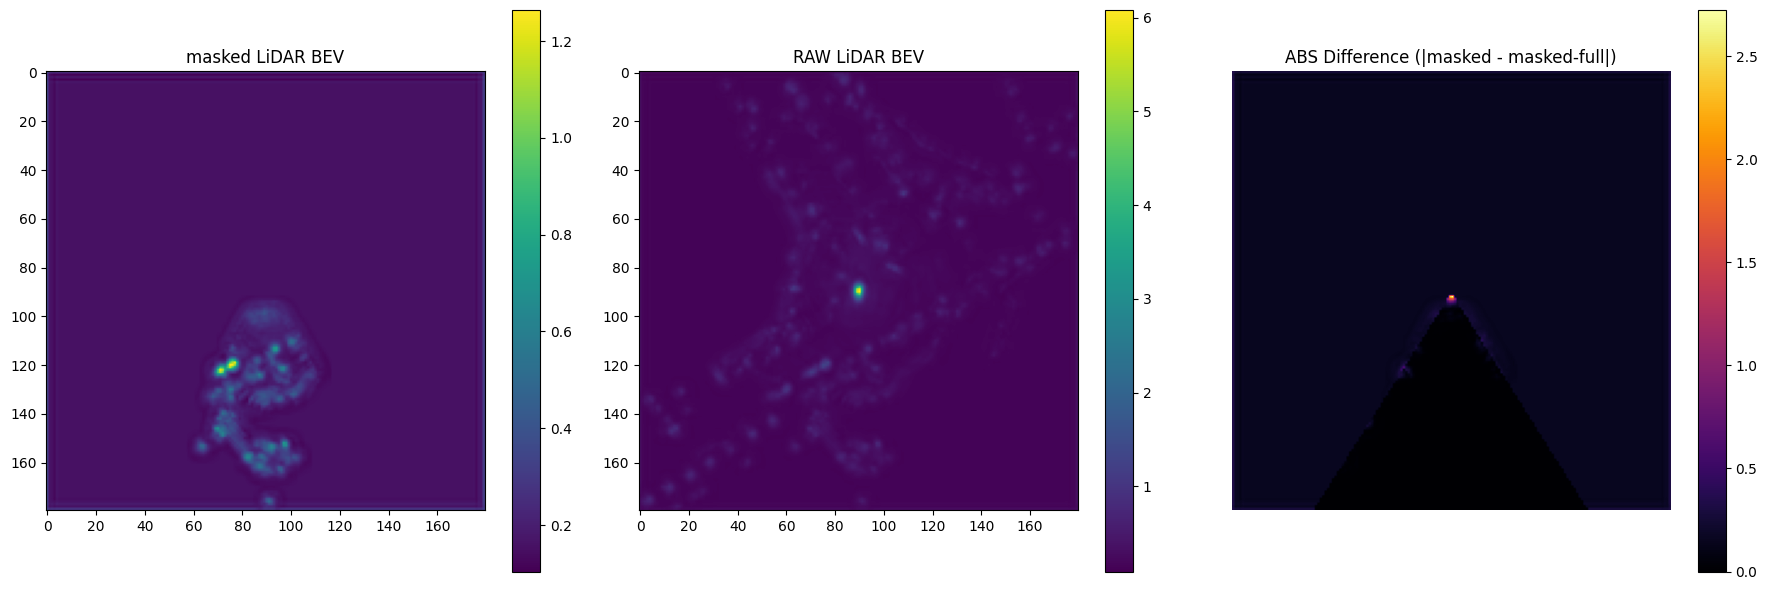

<Figure size 640x480 with 0 Axes>

Processing bev_c2


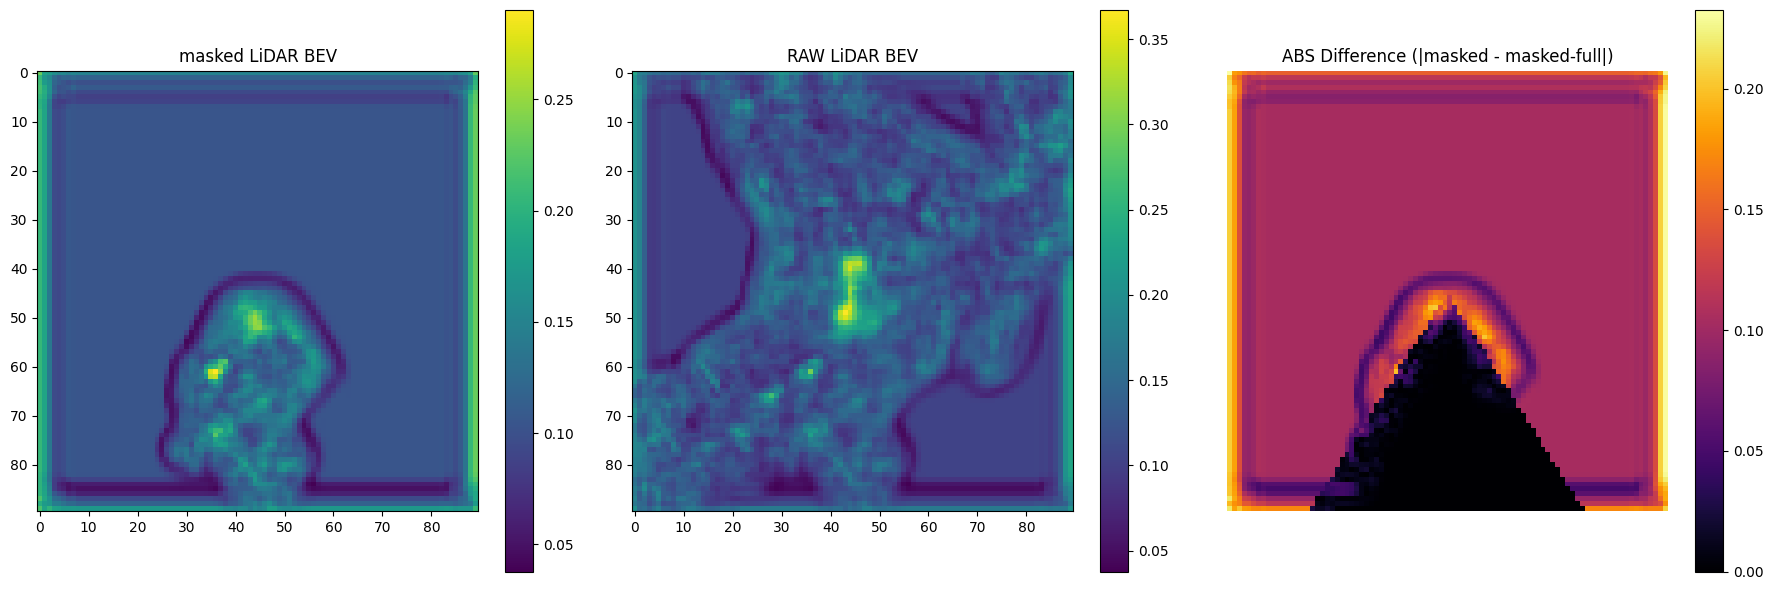

<Figure size 640x480 with 0 Axes>

In [79]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

lidar_file_full = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/benign_early_layers.pt"

cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
# lidar_raw_full = torch.load(lidar_file)["bev_c2"].squeeze(0)   # [C, H, W]


# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)



# lidar_raw_full = torch.rot90(lidar_raw_full, k=-1, dims=[1, 2])


masked_lidar_o = torch.load(lidar_file)
lidar_raw_full_o = torch.load(lidar_file_full)
print(masked_lidar_o.keys())
keys = list(masked_lidar_o.keys())
# keys = np.array(keys)
print(keys)
for i in range(1, len(keys)):  # start from index 1
    key = keys[i]
    print(f"Processing {key}")

    masked_lidar = masked_lidar_o[key].squeeze(0)
    lidar_raw_full = lidar_raw_full_o[key].squeeze(0)
        
    masked_full_lidar = crop_lidar_bev_to_camera_fov(
        lidar_raw_full,
        lidar2img,
        img_shape,
        # bev_resolution=(1.14, 1.14),
        bev_resolution = (0.57, 0.57),
        pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
    )


    class BEVSpec:
        def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
            self.x_min = x_min
            self.x_max = x_max
            self.cell_x = cell_x
            self.y_min = y_min
            self.y_max = y_max
            self.cell_y = cell_y

        @property
        def H(self):
            return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

        @property
        def W(self):
            return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

    bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


    # Lidar masked: [C, H_raw, W_raw] → add batch
    # lidar_masked_full_batch = masked_full_lidar.unsqueeze(0)

    # x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

    # xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
    # ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
    # Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

    # grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
    # grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
    # grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

    # lidar_bev_canonical = F.grid_sample(
    #     lidar_masked_full_batch, grid,
    #     mode='bilinear', padding_mode='zeros', align_corners=True
    # ).squeeze(0)




    masked_lidar_mean = masked_lidar.mean(0).numpy()
    masked_full_lidar_mean = masked_full_lidar.mean(0).numpy()


    # Absolute difference heatmap
    diff = np.abs(masked_full_lidar_mean - masked_lidar_mean)


    plt.figure(figsize=(18, 6))

    # plt.subplot(1, 3, 1)
    # plt.title("RAW LiDAR BEV")
    # plt.imshow(lidar_raw_full.mean(0), cmap='viridis')
    # plt.colorbar()


    plt.subplot(1, 3, 1)
    plt.title("masked LiDAR BEV")
    plt.imshow(masked_lidar.mean(0), cmap='viridis')
    plt.colorbar()


    # plt.subplot(1, 3, 2)
    # plt.title("Masked full LiDAR (FOV Only)")
    # plt.imshow(masked_full_lidar.mean(0), cmap='viridis')
    # plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title("RAW LiDAR BEV")
    plt.imshow(lidar_raw_full.mean(0), cmap='viridis')
    plt.colorbar()



    # ------------ DIFFERENCE -------------
    plt.subplot(1, 3, 3)
    plt.title("ABS Difference (|masked - masked-full|)")
    plt.imshow(diff, cmap="inferno")
    plt.colorbar()
    plt.axis('off')

    plt.tight_layout()
    plt.show()



    # plt.subplot(1, 3, 3)
    # plt.title("Masked → Canonical BEV")
    # plt.imshow(lidar_bev_canonical.mean(0), cmap='viridis')
    # plt.colorbar()

    plt.tight_layout()
    plt.show()



In [17]:
import numpy as np
s = np.array(["spatial", "bev_c1", "bev_c2"])
print(s)
for i in s:
    print(i)

['spatial' 'bev_c1' 'bev_c2']
spatial
bev_c1
bev_c2


In [ ]:

for i in range(0, len(s)):  # start from index 1
    # print(s[i])
    print(f"\"{s[i]}\"")


"spatial"
"bev_c1"
"bev_c2"


In [ ]:

masked_lidar = torch.load(lidar_file)
print(masked_lidar.keys())
keys = list(masked_lidar.keys())
s = np.array(keys)


dict_keys(['voxel_feats', 'spatial', 'bev_c1', 'bev_c2'])


In [ ]:
np.array(keys)

array(['voxel_feats', 'spatial', 'bev_c1', 'bev_c2'], dtype='<U11')

In [61]:
masked_lidar = torch.load(lidar_file)
print(masked_lidar.keys())
keys = list(masked_lidar.keys())
# keys = np.array(keys)
print(keys)
for i in range(0, len(keys)):  # start from index 1

    print(f"'{keys[i]}'")


dict_keys(['voxel_feats', 'spatial', 'bev_c1', 'bev_c2'])
['voxel_feats', 'spatial', 'bev_c1', 'bev_c2']
'voxel_feats'
'spatial'
'bev_c1'
'bev_c2'


In [63]:

masked_lidar[f"{keys[i]}"].squeeze(0)   # [C, H, W]

tensor([[[0.1343, 0.0479, 0.2866,  ..., 0.1070, 0.4350, 0.3641],
         [0.0000, 0.0000, 0.4381,  ..., 0.0000, 0.5212, 0.7447],
         [0.0000, 0.0000, 0.3999,  ..., 0.0000, 0.5781, 0.9871],
         ...,
         [0.1083, 0.0000, 0.4841,  ..., 0.0000, 0.5988, 0.8284],
         [0.3117, 0.0000, 0.7055,  ..., 0.1025, 0.4993, 0.6131],
         [0.7449, 0.2645, 0.4511,  ..., 0.2162, 0.4624, 0.6325]],

        [[0.0925, 0.0000, 0.0000,  ..., 0.0000, 0.0690, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.2061, 0.0949],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.2372],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0245],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.1067, 0.0000, 0.0153,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.2299,  ..., 0.0000, 0.1575, 0.1543],
         [0.0992, 0.2635, 0.4789,  ..., 0.0000, 0.0000, 0.

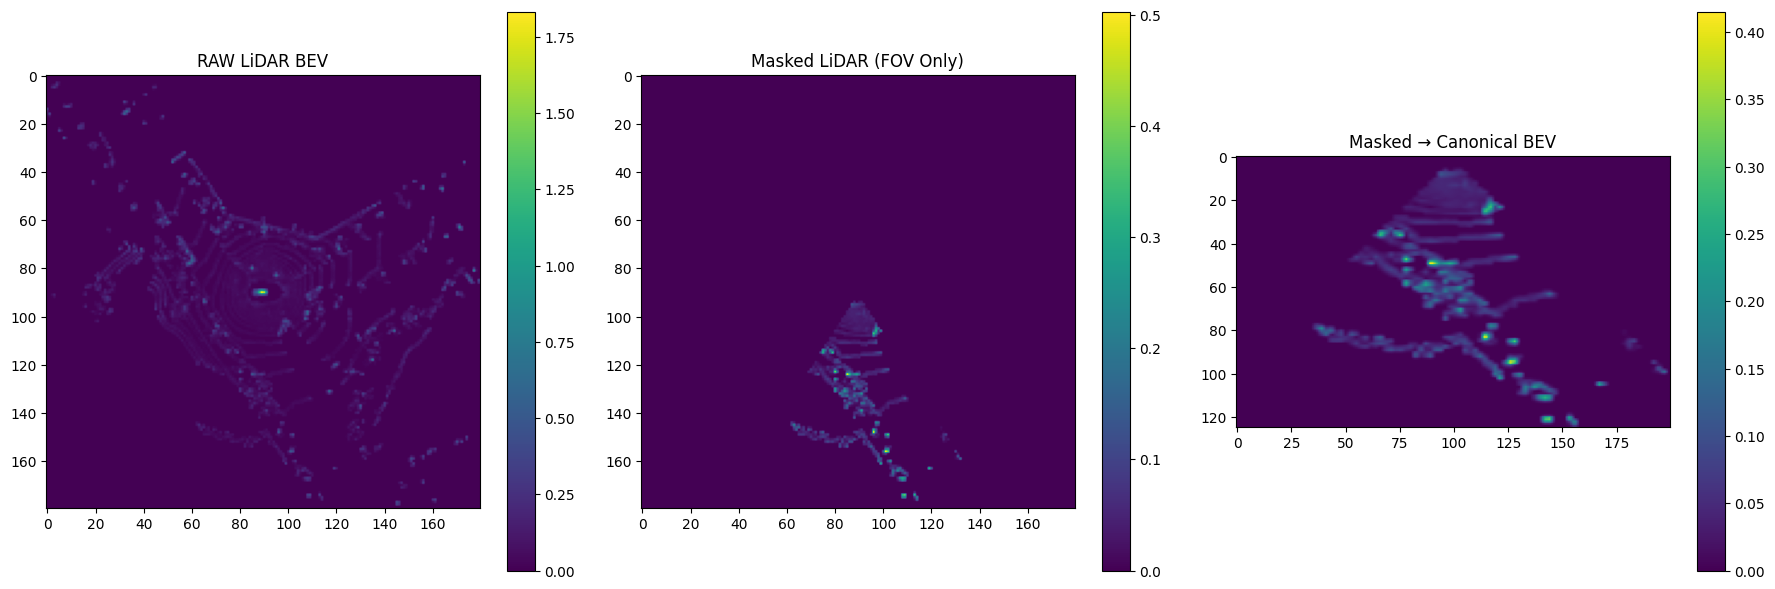

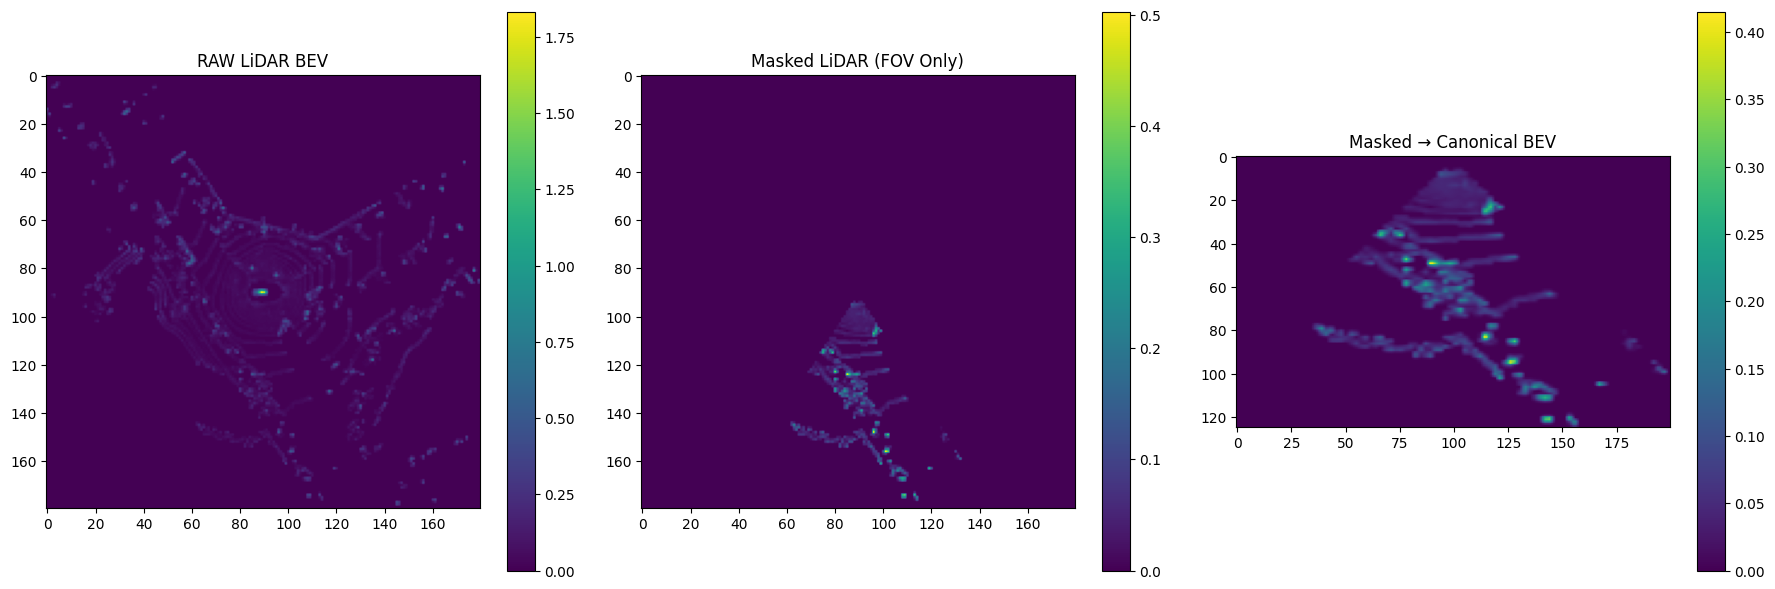

In [ ]:
import os
import glob
import csv
import ast
import torch
import torch.nn.functional as F
from torch.utils.data import ConcatDataset
import numpy as np
from lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov


# ============================================================
# BEV spec
# ============================================================

class BEVSpec:
    """
    Defines the canonical BEV grid for fusion.
    """
    def __init__(self, x_min=0.0, x_max=50.0, cell_x=0.4,
                 y_min=-25.0, y_max=25.0, cell_y=0.25):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))


# ============================================================
# Calibration handling (from calib_trainval_front.csv)
# ============================================================

class CameraCalib:
    """
    Holds per-sample camera & LiDAR calibration.
    """
    def __init__(self, K, R, T, lidar2img, img_shape):
        self.K = K          # 3x3
        self.R = R          # 3x3, cam->ego
        self.T = T          # (3,)
        self.lidar2img = lidar2img  # 3x4
        self.img_shape = img_shape  # (H, W)


def load_calib_db(csv_file, cam_channel="CAM_FRONT"):
    """
    Build a dict:
        (sample_token, cam_channel) -> CameraCalib

    Same parsing semantics as your Jupyter load_calib_from_csv.
    """
    calib_db = {}
    with open(csv_file, mode='r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            token = row["sample_token"]
            ch = row["cam_channel"]
            # Only keep the camera channel we care about (e.g., CAM_FRONT)
            if ch != cam_channel:
                continue

            K = np.array(ast.literal_eval(row["K_flat"]), dtype=np.float64).reshape(3, 3)
            R = np.array(ast.literal_eval(row["R_flat"]), dtype=np.float64).reshape(3, 3)
            T = np.array(ast.literal_eval(row["T_flat"]), dtype=np.float64).reshape(3,)
            lidar2img = np.array(ast.literal_eval(row["lidar2img_flat"]),
                                 dtype=np.float64).reshape(3, 4)
            img_shape = (int(row["img_height"]), int(row["img_width"]))
            calib_db[(token, ch)] = CameraCalib(K=K, R=R, T=T,
                                                lidar2img=lidar2img,
                                                img_shape=img_shape)
    return calib_db


# ============================================================
# Token matching from camera & lidar dirs
# ============================================================

def get_matched_tokens(camera_feat_root, lidar_root, fpn_level):
    """
    Match tokens based on filenames:
      camera: {token}_lvl{fpn}.pt
      lidar:  {token}.pt
    """
    cam_files = glob.glob(os.path.join(camera_feat_root, f"*lvl{fpn_level}.pt"))
    lidar_files = glob.glob(os.path.join(lidar_root, "*.pt"))

    cam_tokens = {
        os.path.basename(f).replace(f"_lvl{fpn_level}.pt", ""): f
        for f in cam_files
    }
    lidar_tokens = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in lidar_files
    }

    matched = sorted(set(cam_tokens.keys()) & set(lidar_tokens.keys()))
    return matched


# ============================================================
# Camera BEV dataset (uses K,R,T,img_shape from calib CSV)
# ============================================================

class TorchCameraBEVDataset:
    """
    Loads and projects FPN camera features into BEV grid using
    explicit calibration (K, R, T) from calib_trainval_front.csv.
    """
    def __init__(self,
                 sample_tokens,
                 camera_feat_root: str,
                 camera_name: str,
                 fpn_level: int,
                 bev_spec: BEVSpec,
                 calib_db: dict):
        self.sample_tokens = sample_tokens
        self.camera_feat_root = camera_feat_root
        self.camera_name = camera_name
        self.fpn_level = fpn_level
        self.bev_spec = bev_spec
        self.calib_db = calib_db

    def __len__(self):
        return len(self.sample_tokens)

    def _lookup_calib(self, token: str) -> CameraCalib:
        key = (token, self.camera_name)
        if key not in self.calib_db:
            raise KeyError(f"Calibration not found for token={token}, cam={self.camera_name}")
        return self.calib_db[key]

    def _load_camera_feat(self, token: str, calib: CameraCalib):
        """
        Load camera FPN feature and compute stride using image shape.
        """
        feat_filename = f"{token}_lvl{self.fpn_level}.pt"
        feat_path = os.path.join(self.camera_feat_root, feat_filename)
        blob = torch.load(feat_path, map_location="cpu")
        cam_feat = blob["feat"]   # [1,C,Hf,Wf] or [C,Hf,Wf]

        if cam_feat.ndim == 3:
            cam_feat = cam_feat.unsqueeze(0)  # [1,C,Hf,Wf]

        Hf, Wf = cam_feat.shape[-2], cam_feat.shape[-1]
        H_img, W_img = calib.img_shape

        # Your Jupyter code did: stride = img_shape[0] // Hf
        # Use float stride for more precision; it's equivalent if divisible.
        stride = H_img / Hf  # assuming same aspect ratio

        self._stride = stride
        self._img_shape = (H_img, W_img)
        return cam_feat

    def __getitem__(self, idx):
        token = self.sample_tokens[idx]
        calib = self._lookup_calib(token)
        cam_feat = self._load_camera_feat(token, calib)  # [1,C,Hf,Wf]
        B, C, Hf, Wf = cam_feat.shape
        stride = self._stride

        # ---- Compute pixel centers (like in your Jupyter code) ----
        i = torch.arange(Hf, dtype=torch.float32) + 0.5
        j = torch.arange(Wf, dtype=torch.float32) + 0.5
        V, U = torch.meshgrid(i * stride, j * stride, indexing='ij')  # [Hf,Wf]

        U = U.numpy()
        V = V.numpy()

        # ---- Backproject rays → camera → ego ----
        K = calib.K
        R_cam2ego = calib.R
        T_cam2ego = calib.T

        K_inv = np.linalg.inv(K)
        uv1 = np.stack([U.reshape(-1), V.reshape(-1), np.ones(Hf * Wf)], axis=0)
        rays_cam = K_inv @ uv1
        rays_cam[1, :] *= -1.0  # flip y (same as your Jupyter code)

        rays_ego = R_cam2ego @ rays_cam
        C_ego = T_cam2ego.reshape(3)

        cam_z = C_ego[2]
        dir_z = rays_ego[2, :]
        s = -cam_z / (dir_z + 1e-12)  # intersection with ground plane z=0
        valid = s > 0

        X = C_ego[0] + s * rays_ego[0, :]
        Y = C_ego[1] + s * rays_ego[1, :]

        # ---- Define canonical BEV grid (same as your Jupyter) ----
        x_min, x_max = self.bev_spec.x_min, self.bev_spec.x_max
        y_min, y_max = self.bev_spec.y_min, self.bev_spec.y_max
        cell_x, cell_y = self.bev_spec.cell_x, self.bev_spec.cell_y
        H_bev, W_bev = self.bev_spec.H, self.bev_spec.W

        bev = torch.zeros((C, H_bev, W_bev), dtype=cam_feat.dtype)

        ix = ((X - x_min) / cell_x).astype(np.int64)
        iy = ((Y - y_min) / cell_y).astype(np.int64)
        inside = valid & (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev)

        feat_flat = cam_feat.reshape(C, -1)  # [C, Hf*Wf]
        idxs = np.where(inside)[0]
        for n in idxs:
            bev[:, ix[n], iy[n]] += feat_flat[:, n]

        # [C,H_bev,W_bev]
        return {
            "cam_bev": bev,
            "image_id": token,
        }

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
        image_ids = [s["image_id"] for s in samples]
        return {
            "cam_bev": cam_bev_batch,
            "image_id": image_ids,
        }


# ============================================================
# LiDAR BEV dataset (uses lidar2img + FOV masking + grid_sample)
# ============================================================

class TorchLidarBEVDataset:
    """
    Loads LiDAR BEV features, masks them to the camera FOV using lidar2img,
    then resamples to the canonical BEV grid.
    """
    def __init__(self,
                 sample_tokens,
                 lidar_root: str,
                 pc_range,
                 bev_spec: BEVSpec,
                 calib_db: dict,
                 camera_name: str):
        self.sample_tokens = sample_tokens
        self.lidar_root = lidar_root
        self.pc_range = pc_range  # e.g., [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
        self.bev_spec = bev_spec
        self.calib_db = calib_db
        self.camera_name = camera_name

    def __len__(self):
        return len(self.sample_tokens)

    def _lookup_calib(self, token: str) -> CameraCalib:
        key = (token, self.camera_name)
        if key not in self.calib_db:
            raise KeyError(f"Calibration not found for token={token}, cam={self.camera_name}")
        return self.calib_db[key]

    def _load_lidar_feat(self, token: str):
        """
        Load LiDAR BEV tensor for a token.
        You used blob['spatial'].squeeze(0) in your notebook.
        """
        feat_path = os.path.join(self.lidar_root, f"{token}.pt")
        blob = torch.load(feat_path, map_location="cpu")

        if "spatial" in blob:
            lidar_feat = blob["spatial"]
        # if "bev_c1" in blob:
        #     lidar_feat = blob["bev_c1"]

        else:
            # fallback if stored as "feat"
            lidar_feat = blob["feat"]
            # lidar_feat = blob["spatial"]

        if lidar_feat.ndim == 3:
            lidar_feat = lidar_feat.unsqueeze(0)  # [1, C, H_raw, W_raw]

        return lidar_feat

    def __getitem__(self, idx):
        token = self.sample_tokens[idx]
        calib = self._lookup_calib(token)
        lidar_feat = self._load_lidar_feat(token)  # [1, C, H_raw, W_raw]
        B, C, H_raw, W_raw = lidar_feat.shape
        assert B == 1, "Expected LiDAR feat with batch dim 1."

        lidar_bev = lidar_feat.squeeze(0)  # [C, H_raw, W_raw]

        x_min_l, y_min_l, _, x_max_l, y_max_l, _ = self.pc_range

        # ---- Compute BEV resolution from pc_range & raw shape ----
        # (You used bev_resolution=(0.57,0.57) in the notebook; here we compute it generically.)
        bev_res_x = (x_max_l - x_min_l) / H_raw
        bev_res_y = (y_max_l - y_min_l) / W_raw
        bev_resolution = (bev_res_x, bev_res_y)

        # ---- FOV masking using lidar2img + img_shape ----
        lidar2img = calib.lidar2img
        img_shape = calib.img_shape  # (H_img, W_img)

        masked_lidar = crop_lidar_bev_to_camera_fov(
            lidar_bev,            # [C, H_raw, W_raw]
            lidar2img,            # 3x4 numpy array
            img_shape,            # (H, W)
            bev_resolution=bev_resolution,
            pc_range=self.pc_range,
        )  # [C, H_raw, W_raw] masked to camera FOV
        
        # masked_lidar = lidar_bev # no masking for testing

        # ---- Resample masked LiDAR into canonical BEV grid via grid_sample ----
        masked_lidar_batch = masked_lidar.unsqueeze(0)  # [1, C, H_raw, W_raw]

        H_cam = self.bev_spec.H
        W_cam = self.bev_spec.W
        cell_x = (self.bev_spec.x_max - self.bev_spec.x_min) / H_cam
        cell_y = (self.bev_spec.y_max - self.bev_spec.y_min) / W_cam

        xs = self.bev_spec.x_min + (torch.arange(H_cam, dtype=torch.float32) + 0.5) * cell_x
        ys = self.bev_spec.y_min + (torch.arange(W_cam, dtype=torch.float32) + 0.5) * cell_y
        Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

        grid_x = 2.0 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1.0
        grid_y = 2.0 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1.0
        grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)  # [1, H_cam, W_cam, 2]

        lidar_bev_canonical = F.grid_sample(
            masked_lidar_batch,
            grid,
            mode='bilinear',
            padding_mode='zeros',
            align_corners=True
        ).squeeze(0)  # [C, H_cam, W_cam]

        return {
            "lidar_bev": lidar_bev_canonical,
            "image_id": token,
        }


# ============================================================
# Wrapper dataset to return (cam_bev, lidar_bev) pairs
# ============================================================

class WrappedConcatBEVDataset(ConcatDataset):
    """
    Returns paired (camera, lidar) BEV tensors for each token.
    """
    def __init__(self,
                 cam_dataset: TorchCameraBEVDataset,
                 lidar_dataset: TorchLidarBEVDataset):
        assert len(cam_dataset) == len(lidar_dataset), \
            "Camera and LiDAR token sets must align 1:1."
        super().__init__([cam_dataset, lidar_dataset])
        self.cam_dataset = cam_dataset
        self.lidar_dataset = lidar_dataset

    def __len__(self):
        return min(len(self.cam_dataset), len(self.lidar_dataset))

    def __getitem__(self, idx):
        cam_sample = self.cam_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        if cam_sample["image_id"] != lidar_sample["image_id"]:
            return None
        return {
            "cam_bev": cam_sample["cam_bev"],
            "lidar_bev": lidar_sample["lidar_bev"],
            "image_id": cam_sample["image_id"],
            "label": 1,
        }

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
        lidar_bev_batch = torch.stack([s["lidar_bev"] for s in samples])
        image_ids = [s["image_id"] for s in samples]
        labels = torch.tensor([s["label"] for s in samples])
        return {
            "cam_bev": cam_bev_batch,
            "lidar_bev": lidar_bev_batch,
            "image_id": image_ids,
            "label": labels,
        }


# ============================================================
# main(): same style as your simple example
# ============================================================
def main():
    # ---- Paths (you can change these later) ----
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT"  # where {token}_lvl0.pt live
    lidar_dir = "/data/nusc_lidar/train"    # where {token}.pt live
    calib_csv = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/final_resources/calib_trainval_front.csv"

    camera_name = "CAM_FRONT"
    fpn_level = 0
    pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]

    bev_spec = BEVSpec(
        x_min=0.0, x_max=50.0, cell_x=0.4,
        y_min=-25.0, y_max=25.0, cell_y=0.25,
    )

    # ---- Load calibration DB once ----
    calib_db = load_calib_db(calib_csv, cam_channel=camera_name)
    print(f"Loaded {len(calib_db)} calibration entries for {camera_name}.")

    # ---- Match tokens from camera + lidar dirs ----
    tokens = get_matched_tokens(camera_dir, lidar_dir, fpn_level=fpn_level)
    print(f"Found {len(tokens)} matched tokens.")

    # ---- Instantiate datasets ----
    cam_ds = TorchCameraBEVDataset(
        sample_tokens=tokens,
        camera_feat_root=camera_dir,
        camera_name=camera_name,
        fpn_level=fpn_level,
        bev_spec=bev_spec,
        calib_db=calib_db,
    )

    lidar_ds = TorchLidarBEVDataset(
        sample_tokens=tokens,
        lidar_root=lidar_dir,
        pc_range=pc_range,
        bev_spec=bev_spec,
        calib_db=calib_db,
        camera_name=camera_name,
    )

    dataset = WrappedConcatBEVDataset(cam_ds, lidar_ds)

    # ---- Inspect a few samples ----
    for i in range(min(3, len(dataset))):
        sample = dataset[i]
        if sample is None:
            continue
        print(f"\nSample {i}:")
        print(f"Camera BEV shape: {tuple(sample['cam_bev'].shape)}")
        print(f"LiDAR  BEV shape: {tuple(sample['lidar_bev'].shape)}")
        print(f"Token/Image ID:  {sample['image_id']}")
        print(f"Label:           {sample['label']}")
        
    return dataset  
if __name__ == "__main__":
    dataset = main()


Loaded 34149 calibration entries for CAM_FRONT.
Found 11547 matched tokens.

Sample 0:
Camera BEV shape: (256, 125, 200)
LiDAR  BEV shape: (256, 125, 200)
Token/Image ID:  00014584c6de4789a69b4717fa3c0d22
Label:           1

Sample 1:
Camera BEV shape: (256, 125, 200)
LiDAR  BEV shape: (256, 125, 200)
Token/Image ID:  000bc348ae6541abac85e51b266039b5
Label:           1

Sample 2:
Camera BEV shape: (256, 125, 200)
LiDAR  BEV shape: (256, 125, 200)
Token/Image ID:  000cf4dfaab54d21a7314036fde74966
Label:           1


  Camera BEV stats:
    Mean: 0.1350   Max: 1200.0695   Min: -1034.0419
  LiDAR  BEV stats:
    Mean: 0.0103   Max: 11.6276   Min: 0.0000


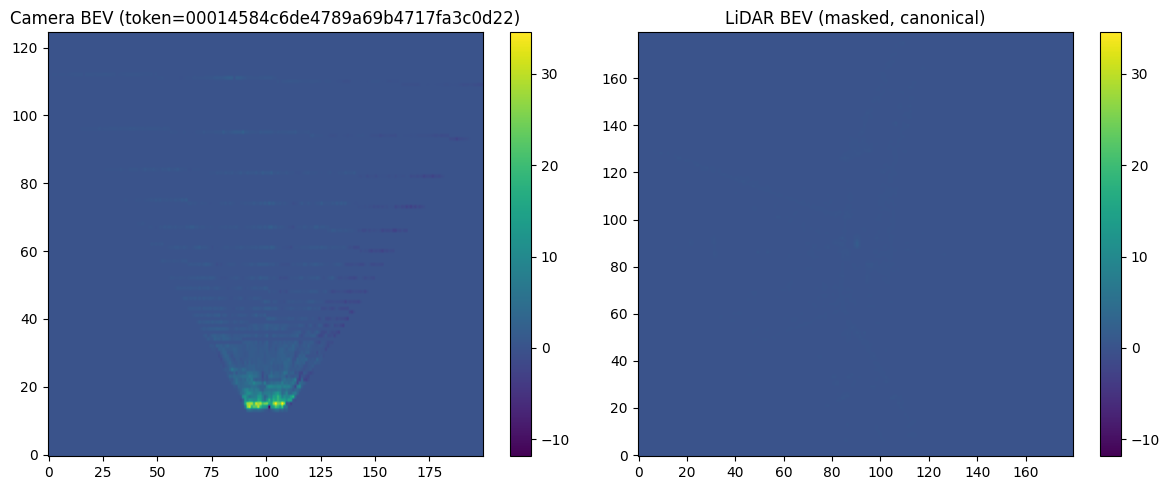

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cam_lidar_bevs(sample, vmin=None, vmax=None):
    """
    Plots camera BEV and LiDAR BEV side by side for a sample.
    Args:
        sample: dict with keys "cam_bev", "lidar_bev", "image_id"
    """
    cam_bev = sample["cam_bev"].detach().cpu().numpy()  # [C, H, W]
    lidar_bev = sample["lidar_bev"].detach().cpu().numpy()  # [C, H, W]

    # Project to a single heatmap (mean over channels)
    cam_bev_img = cam_bev.mean(0)
    lidar_bev_img = lidar_bev.mean(0)

    # Normalize for fair comparison, if desired
    if vmin is None:
        vmin = min(cam_bev_img.min(), lidar_bev_img.min())
    if vmax is None:
        vmax = max(cam_bev_img.max(), lidar_bev_img.max())





    # Print stats for Camera BEV
    print("  Camera BEV stats:")
    print(f"    Mean: {sample['cam_bev'].mean().item():.4f}   Max: {sample['cam_bev'].max().item():.4f}   Min: {sample['cam_bev'].min().item():.4f}")

    # Print stats for LiDAR BEV
    print("  LiDAR  BEV stats:")
    print(f"    Mean: {sample['lidar_bev'].mean().item():.4f}   Max: {sample['lidar_bev'].max().item():.4f}   Min: {sample['lidar_bev'].min().item():.4f}")

    
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.title(f"Camera BEV (token={sample['image_id']})")
    plt.imshow(cam_bev_img, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("LiDAR BEV (masked, canonical)")
    plt.imshow(lidar_bev_img, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

# Example usage: plot the first sample in the dataset
sample = dataset[0]  # or any other index
if sample is not None:
    plot_cam_lidar_bevs(sample)


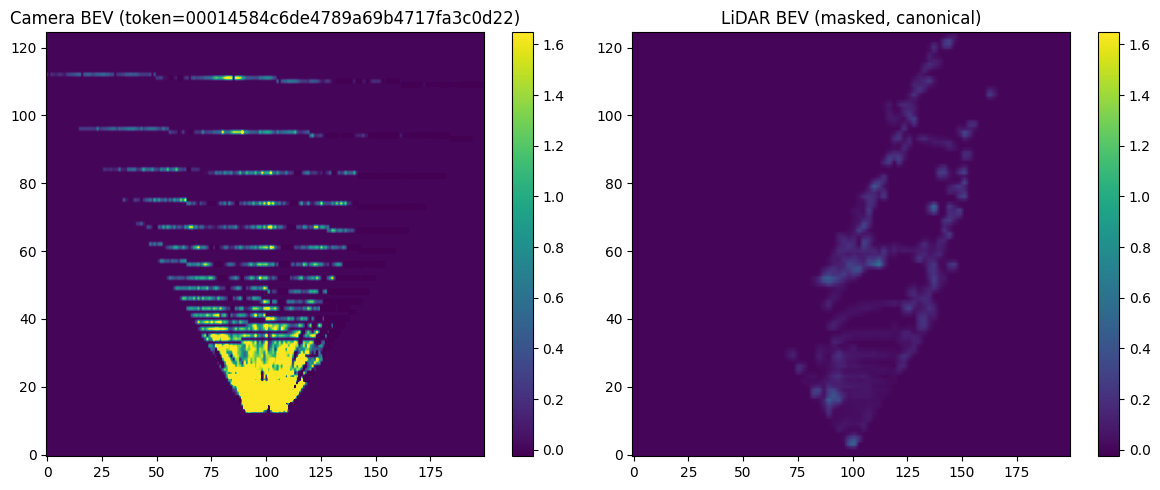

In [17]:
def plot_cam_lidar_bevs(sample, clip_percentile=99):
    import matplotlib.pyplot as plt
    import numpy as np

    cam_bev = sample["cam_bev"].detach().cpu().numpy()
    lidar_bev = sample["lidar_bev"].detach().cpu().numpy()

    cam_bev_img = cam_bev.mean(0)
    lidar_bev_img = lidar_bev.mean(0)

    # Calculate robust color limits
    all_vals = np.concatenate([cam_bev_img.flatten(), lidar_bev_img.flatten()])
    vmax = np.percentile(all_vals, clip_percentile)
    vmin = np.percentile(all_vals, 100 - clip_percentile)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.title(f"Camera BEV (token={sample['image_id']})")
    plt.imshow(cam_bev_img, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("LiDAR BEV (masked, canonical)")
    plt.imshow(lidar_bev_img, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    plt.colorbar()

    plt.tight_layout()
    plt.show()


    
# Example usage: plot the first sample in the dataset
sample = dataset[0]  # or any other index
if sample is not None:
    plot_cam_lidar_bevs(sample)



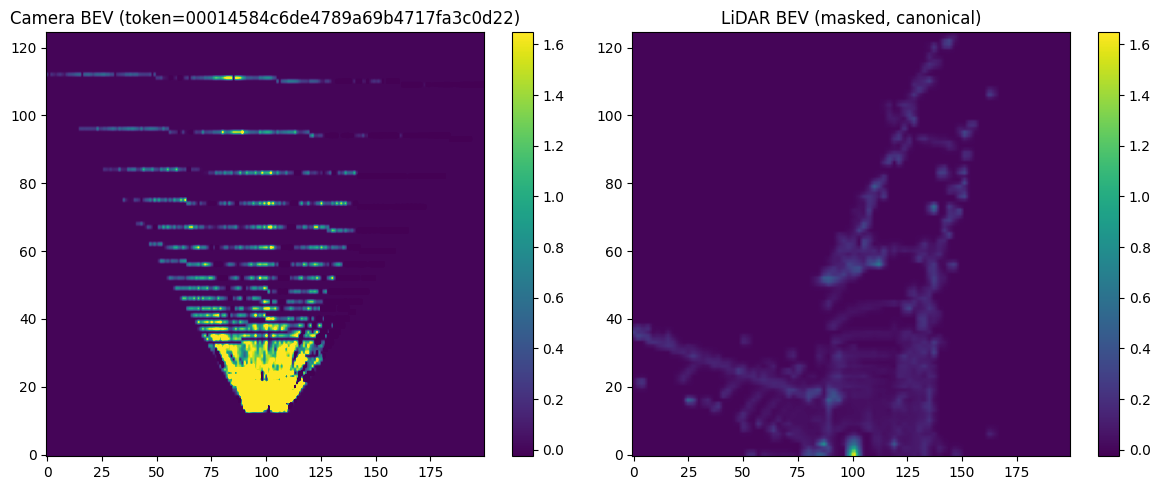

In [19]:
def plot_cam_lidar_bevs(sample, clip_percentile=99):
    import matplotlib.pyplot as plt
    import numpy as np

    cam_bev = sample["cam_bev"].detach().cpu().numpy()
    lidar_bev = sample["lidar_bev"].detach().cpu().numpy()

    cam_bev_img = cam_bev.mean(0)
    lidar_bev_img = lidar_bev.mean(0)

    # Calculate robust color limits
    all_vals = np.concatenate([cam_bev_img.flatten(), lidar_bev_img.flatten()])
    vmax = np.percentile(all_vals, clip_percentile)
    vmin = np.percentile(all_vals, 100 - clip_percentile)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.title(f"Camera BEV (token={sample['image_id']})")
    plt.imshow(cam_bev_img, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("LiDAR BEV (masked, canonical)")
    plt.imshow(lidar_bev_img, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    plt.colorbar()

    plt.tight_layout()
    plt.show()


    
# Example usage: plot the first sample in the dataset
sample = dataset[0]  # or any other index
if sample is not None:
    plot_cam_lidar_bevs(sample)



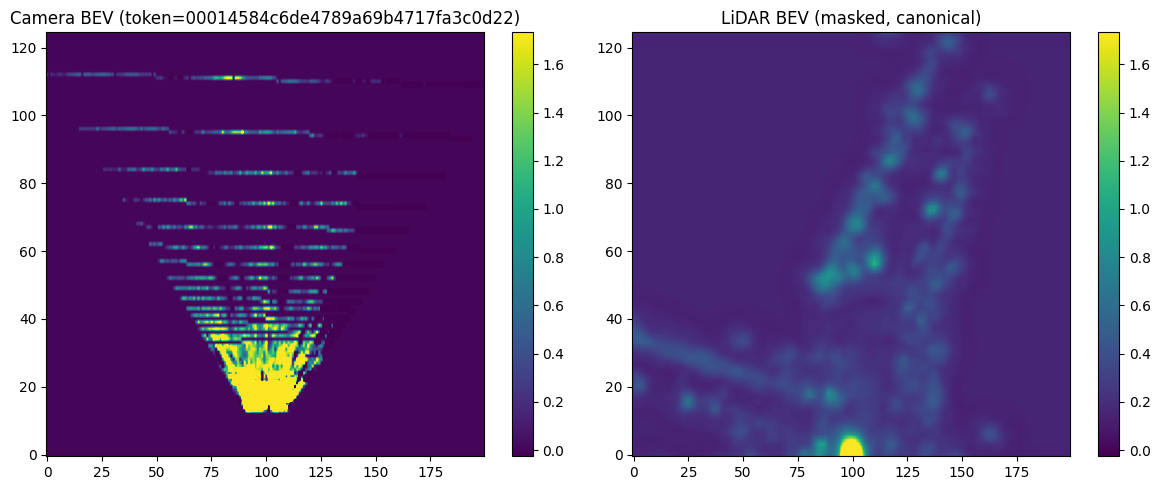

In [21]:
def plot_cam_lidar_bevs(sample, clip_percentile=99):
    import matplotlib.pyplot as plt
    import numpy as np

    cam_bev = sample["cam_bev"].detach().cpu().numpy()
    lidar_bev = sample["lidar_bev"].detach().cpu().numpy()

    cam_bev_img = cam_bev.mean(0)
    lidar_bev_img = lidar_bev.mean(0)

    # Calculate robust color limits
    all_vals = np.concatenate([cam_bev_img.flatten(), lidar_bev_img.flatten()])
    vmax = np.percentile(all_vals, clip_percentile)
    vmin = np.percentile(all_vals, 100 - clip_percentile)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.title(f"Camera BEV (token={sample['image_id']})")
    plt.imshow(cam_bev_img, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("LiDAR BEV (masked, canonical)")
    plt.imshow(lidar_bev_img, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    plt.colorbar()

    plt.tight_layout()
    plt.show()


    
# Example usage: plot the first sample in the dataset
sample = dataset[0]  # or any other index
if sample is not None:
    plot_cam_lidar_bevs(sample)



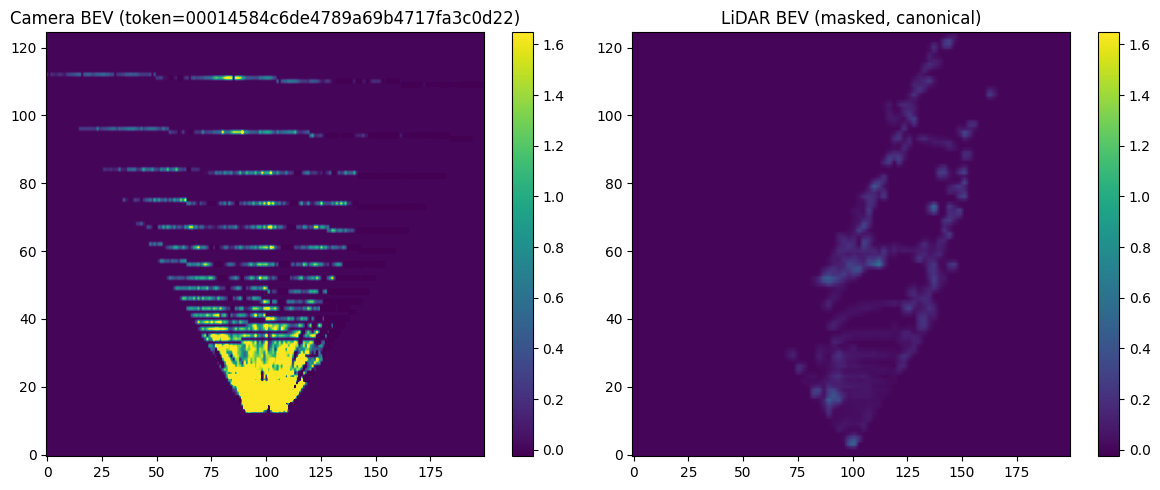

In [26]:
def plot_cam_lidar_bevs(sample, clip_percentile=99):
    import matplotlib.pyplot as plt
    import numpy as np

    cam_bev = sample["cam_bev"].detach().cpu().numpy()
    lidar_bev = sample["lidar_bev"].detach().cpu().numpy()

    cam_bev_img = cam_bev.mean(0)
    lidar_bev_img = lidar_bev.mean(0)

    # Calculate robust color limits
    all_vals = np.concatenate([cam_bev_img.flatten(), lidar_bev_img.flatten()])
    vmax = np.percentile(all_vals, clip_percentile)
    vmin = np.percentile(all_vals, 100 - clip_percentile)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.title(f"Camera BEV (token={sample['image_id']})")
    plt.imshow(cam_bev_img, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("LiDAR BEV (masked, canonical)")
    plt.imshow(lidar_bev_img, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    plt.colorbar()

    plt.tight_layout()
    plt.show()


    
# Example usage: plot the first sample in the dataset
sample = dataset[0]  # or any other index
if sample is not None:
    plot_cam_lidar_bevs(sample)



In [28]:
import os
import glob
import shutil
import random

# -- Source directories
camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT"
lidar_dir = "/data/nusc_lidar/train"
fpn_level = 0

# -- Target (tiny) directories
tiny_root = "/data/nusc_tiny"
os.makedirs(f"{tiny_root}/train/lidar", exist_ok=True)
os.makedirs(f"{tiny_root}/train/fpn/CAM_FRONT", exist_ok=True)
os.makedirs(f"{tiny_root}/validation/lidar", exist_ok=True)
os.makedirs(f"{tiny_root}/validation/fpn/CAM_FRONT", exist_ok=True)

# -- Find all matching tokens
cam_files = glob.glob(os.path.join(camera_dir, f"*lvl{fpn_level}.pt"))
lidar_files = glob.glob(os.path.join(lidar_dir, "*.pt"))

cam_tokens = {os.path.basename(f).replace(f"_lvl{fpn_level}.pt", "") for f in cam_files}
lidar_tokens = {os.path.splitext(os.path.basename(f))[0] for f in lidar_files}
matched_tokens = sorted(list(cam_tokens & lidar_tokens))

print(f"Found {len(matched_tokens)} matched samples.")

# -- Select 12 random samples (for reproducibility set random.seed)
random.seed(0)
selected_tokens = random.sample(matched_tokens, 12)
print("Selected tokens:", selected_tokens)

# -- Split: 6 train, 6 val
train_tokens = selected_tokens[:12]
val_tokens = selected_tokens[12:]

# -- Helper: copy files for a split
def copy_tiny_split(tokens, split):
    cam_out = f"{tiny_root}/{split}/fpn/CAM_FRONT"
    lidar_out = f"{tiny_root}/{split}/lidar"
    for t in tokens:
        cam_src = os.path.join(camera_dir, f"{t}_lvl{fpn_level}.pt")
        lidar_src = os.path.join(lidar_dir, f"{t}.pt")
        cam_dst = os.path.join(cam_out, f"{t}_lvl{fpn_level}.pt")
        lidar_dst = os.path.join(lidar_out, f"{t}.pt")
        shutil.copy2(cam_src, cam_dst)
        shutil.copy2(lidar_src, lidar_dst)
        print(f"Copied: {t}")

copy_tiny_split(train_tokens, "train")
copy_tiny_split(val_tokens, "validation")

print("Tiny dataset created!")


Found 11547 matched samples.
Selected tokens: ['8b0e414172414d679a03df7dc30d25f4', '96ecbc844fc34371b1282bc7f0632e77', '0de98987fe07471ba19ad40e57a597a6', '5d752493741d45d7a0adf37432b9f73d', 'b8d4d48ad1f6426c851ec672df731011', 'af752d2661674869a82fafe8964dbb43', '914e93fb7bc146d3af9c73adf7183fc3', '6d450599d315481e990652bcd9876f7d', 'ab8bb06d76ba4c38b370e17d3cd1f988', '8177ec02c79340fb9021cc86feec3d74', 'd39b9e84ac07407882a8f6de3dbb2c32', '4f6eb8cab70342a7840c8e5f095ba871']
Copied: 8b0e414172414d679a03df7dc30d25f4
Copied: 96ecbc844fc34371b1282bc7f0632e77
Copied: 0de98987fe07471ba19ad40e57a597a6
Copied: 5d752493741d45d7a0adf37432b9f73d
Copied: b8d4d48ad1f6426c851ec672df731011
Copied: af752d2661674869a82fafe8964dbb43
Copied: 914e93fb7bc146d3af9c73adf7183fc3
Copied: 6d450599d315481e990652bcd9876f7d
Copied: ab8bb06d76ba4c38b370e17d3cd1f988
Copied: 8177ec02c79340fb9021cc86feec3d74
Copied: d39b9e84ac07407882a8f6de3dbb2c32
Copied: 4f6eb8cab70342a7840c8e5f095ba871
Tiny dataset created!


In [29]:
import os
import glob
import csv
import ast
import torch
import torch.nn.functional as F
from torch.utils.data import ConcatDataset
import numpy as np
from lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov


# ============================================================
# BEV spec
# ============================================================

class BEVSpec:
    """
    Defines the canonical BEV grid for fusion.
    """
    def __init__(self, x_min=0.0, x_max=50.0, cell_x=0.4,
                 y_min=-25.0, y_max=25.0, cell_y=0.25):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))


# ============================================================
# Calibration handling (from calib_trainval_front.csv)
# ============================================================

class CameraCalib:
    """
    Holds per-sample camera & LiDAR calibration.
    """
    def __init__(self, K, R, T, lidar2img, img_shape):
        self.K = K          # 3x3
        self.R = R          # 3x3, cam->ego
        self.T = T          # (3,)
        self.lidar2img = lidar2img  # 3x4
        self.img_shape = img_shape  # (H, W)


def load_calib_db(csv_file, cam_channel="CAM_FRONT"):
    """
    Build a dict:
        (sample_token, cam_channel) -> CameraCalib

    Same parsing semantics as your Jupyter load_calib_from_csv.
    """
    calib_db = {}
    with open(csv_file, mode='r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            token = row["sample_token"]
            ch = row["cam_channel"]
            # Only keep the camera channel we care about (e.g., CAM_FRONT)
            if ch != cam_channel:
                continue

            K = np.array(ast.literal_eval(row["K_flat"]), dtype=np.float64).reshape(3, 3)
            R = np.array(ast.literal_eval(row["R_flat"]), dtype=np.float64).reshape(3, 3)
            T = np.array(ast.literal_eval(row["T_flat"]), dtype=np.float64).reshape(3,)
            lidar2img = np.array(ast.literal_eval(row["lidar2img_flat"]),
                                 dtype=np.float64).reshape(3, 4)
            img_shape = (int(row["img_height"]), int(row["img_width"]))
            calib_db[(token, ch)] = CameraCalib(K=K, R=R, T=T,
                                                lidar2img=lidar2img,
                                                img_shape=img_shape)
    return calib_db


# ============================================================
# Token matching from camera & lidar dirs
# ============================================================

def get_matched_tokens(camera_feat_root, lidar_root, fpn_level):
    """
    Match tokens based on filenames:
      camera: {token}_lvl{fpn}.pt
      lidar:  {token}.pt
    """
    cam_files = glob.glob(os.path.join(camera_feat_root, f"*lvl{fpn_level}.pt"))
    lidar_files = glob.glob(os.path.join(lidar_root, "*.pt"))

    cam_tokens = {
        os.path.basename(f).replace(f"_lvl{fpn_level}.pt", ""): f
        for f in cam_files
    }
    lidar_tokens = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in lidar_files
    }

    matched = sorted(set(cam_tokens.keys()) & set(lidar_tokens.keys()))
    return matched


# ============================================================
# Camera BEV dataset (uses K,R,T,img_shape from calib CSV)
# ============================================================

class TorchCameraBEVDataset:
    """
    Loads and projects FPN camera features into BEV grid using
    explicit calibration (K, R, T) from calib_trainval_front.csv.
    """
    def __init__(self,
                 sample_tokens,
                 camera_feat_root: str,
                 camera_name: str,
                 fpn_level: int,
                 bev_spec: BEVSpec,
                 calib_db: dict):
        self.sample_tokens = sample_tokens
        self.camera_feat_root = camera_feat_root
        self.camera_name = camera_name
        self.fpn_level = fpn_level
        self.bev_spec = bev_spec
        self.calib_db = calib_db

    def __len__(self):
        return len(self.sample_tokens)

    def _lookup_calib(self, token: str) -> CameraCalib:
        key = (token, self.camera_name)
        if key not in self.calib_db:
            raise KeyError(f"Calibration not found for token={token}, cam={self.camera_name}")
        return self.calib_db[key]

    def _load_camera_feat(self, token: str, calib: CameraCalib):
        """
        Load camera FPN feature and compute stride using image shape.
        """
        feat_filename = f"{token}_lvl{self.fpn_level}.pt"
        feat_path = os.path.join(self.camera_feat_root, feat_filename)
        blob = torch.load(feat_path, map_location="cpu")
        cam_feat = blob["feat"]   # [1,C,Hf,Wf] or [C,Hf,Wf]

        if cam_feat.ndim == 3:
            cam_feat = cam_feat.unsqueeze(0)  # [1,C,Hf,Wf]

        Hf, Wf = cam_feat.shape[-2], cam_feat.shape[-1]
        H_img, W_img = calib.img_shape

        # Your Jupyter code did: stride = img_shape[0] // Hf
        # Use float stride for more precision; it's equivalent if divisible.
        stride = H_img / Hf  # assuming same aspect ratio

        self._stride = stride
        self._img_shape = (H_img, W_img)
        return cam_feat

    def __getitem__(self, idx):
        token = self.sample_tokens[idx]
        calib = self._lookup_calib(token)
        cam_feat = self._load_camera_feat(token, calib)  # [1,C,Hf,Wf]
        B, C, Hf, Wf = cam_feat.shape
        stride = self._stride

        # ---- Compute pixel centers (like in your Jupyter code) ----
        i = torch.arange(Hf, dtype=torch.float32) + 0.5
        j = torch.arange(Wf, dtype=torch.float32) + 0.5
        V, U = torch.meshgrid(i * stride, j * stride, indexing='ij')  # [Hf,Wf]

        U = U.numpy()
        V = V.numpy()

        # ---- Backproject rays → camera → ego ----
        K = calib.K
        R_cam2ego = calib.R
        T_cam2ego = calib.T

        K_inv = np.linalg.inv(K)
        uv1 = np.stack([U.reshape(-1), V.reshape(-1), np.ones(Hf * Wf)], axis=0)
        rays_cam = K_inv @ uv1
        rays_cam[1, :] *= -1.0  # flip y (same as your Jupyter code)

        rays_ego = R_cam2ego @ rays_cam
        C_ego = T_cam2ego.reshape(3)

        cam_z = C_ego[2]
        dir_z = rays_ego[2, :]
        s = -cam_z / (dir_z + 1e-12)  # intersection with ground plane z=0
        valid = s > 0

        X = C_ego[0] + s * rays_ego[0, :]
        Y = C_ego[1] + s * rays_ego[1, :]

        # ---- Define canonical BEV grid (same as your Jupyter) ----
        x_min, x_max = self.bev_spec.x_min, self.bev_spec.x_max
        y_min, y_max = self.bev_spec.y_min, self.bev_spec.y_max
        cell_x, cell_y = self.bev_spec.cell_x, self.bev_spec.cell_y
        H_bev, W_bev = self.bev_spec.H, self.bev_spec.W

        bev = torch.zeros((C, H_bev, W_bev), dtype=cam_feat.dtype)

        ix = ((X - x_min) / cell_x).astype(np.int64)
        iy = ((Y - y_min) / cell_y).astype(np.int64)
        inside = valid & (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev)

        feat_flat = cam_feat.reshape(C, -1)  # [C, Hf*Wf]
        idxs = np.where(inside)[0]
        for n in idxs:
            bev[:, ix[n], iy[n]] += feat_flat[:, n]

        # [C,H_bev,W_bev]
        return {
            "cam_bev": bev,
            "image_id": token,
        }

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
        image_ids = [s["image_id"] for s in samples]
        return {
            "cam_bev": cam_bev_batch,
            "image_id": image_ids,
        }


# ============================================================
# LiDAR BEV dataset (uses lidar2img + FOV masking + grid_sample)
# ============================================================

class TorchLidarBEVDataset:
    """
    Loads LiDAR BEV features, masks them to the camera FOV using lidar2img,
    then resamples to the canonical BEV grid.
    """
    def __init__(self,
                 sample_tokens,
                 lidar_root: str,
                 pc_range,
                 bev_spec: BEVSpec,
                 calib_db: dict,
                 camera_name: str):
        self.sample_tokens = sample_tokens
        self.lidar_root = lidar_root
        self.pc_range = pc_range  # e.g., [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
        self.bev_spec = bev_spec
        self.calib_db = calib_db
        self.camera_name = camera_name

    def __len__(self):
        return len(self.sample_tokens)

    def _lookup_calib(self, token: str) -> CameraCalib:
        key = (token, self.camera_name)
        if key not in self.calib_db:
            raise KeyError(f"Calibration not found for token={token}, cam={self.camera_name}")
        return self.calib_db[key]

    def _load_lidar_feat(self, token: str):
        """
        Load LiDAR BEV tensor for a token.
        You used blob['spatial'].squeeze(0) in your notebook.
        """
        feat_path = os.path.join(self.lidar_root, f"{token}.pt")
        blob = torch.load(feat_path, map_location="cpu")

        if "spatial" in blob:
            lidar_feat = blob["spatial"]
        # if "bev_c1" in blob:
        #     lidar_feat = blob["bev_c1"]

        else:
            # fallback if stored as "feat"
            lidar_feat = blob["feat"]
            # lidar_feat = blob["spatial"]

        if lidar_feat.ndim == 3:
            lidar_feat = lidar_feat.unsqueeze(0)  # [1, C, H_raw, W_raw]

        return lidar_feat

    def __getitem__(self, idx):
        token = self.sample_tokens[idx]
        calib = self._lookup_calib(token)
        lidar_feat = self._load_lidar_feat(token)  # [1, C, H_raw, W_raw]
        B, C, H_raw, W_raw = lidar_feat.shape
        assert B == 1, "Expected LiDAR feat with batch dim 1."

        lidar_bev = lidar_feat.squeeze(0)  # [C, H_raw, W_raw]

        x_min_l, y_min_l, _, x_max_l, y_max_l, _ = self.pc_range

        # ---- Compute BEV resolution from pc_range & raw shape ----
        # (You used bev_resolution=(0.57,0.57) in the notebook; here we compute it generically.)
        bev_res_x = (x_max_l - x_min_l) / H_raw
        bev_res_y = (y_max_l - y_min_l) / W_raw
        bev_resolution = (bev_res_x, bev_res_y)

        # ---- FOV masking using lidar2img + img_shape ----
        lidar2img = calib.lidar2img
        img_shape = calib.img_shape  # (H_img, W_img)

        masked_lidar = crop_lidar_bev_to_camera_fov(
            lidar_bev,            # [C, H_raw, W_raw]
            lidar2img,            # 3x4 numpy array
            img_shape,            # (H, W)
            bev_resolution=bev_resolution,
            pc_range=self.pc_range,
        )  # [C, H_raw, W_raw] masked to camera FOV
        
        # masked_lidar = lidar_bev # no masking for testing

        # ---- Resample masked LiDAR into canonical BEV grid via grid_sample ----
        masked_lidar_batch = masked_lidar.unsqueeze(0)  # [1, C, H_raw, W_raw]

        H_cam = self.bev_spec.H
        W_cam = self.bev_spec.W
        cell_x = (self.bev_spec.x_max - self.bev_spec.x_min) / H_cam
        cell_y = (self.bev_spec.y_max - self.bev_spec.y_min) / W_cam

        xs = self.bev_spec.x_min + (torch.arange(H_cam, dtype=torch.float32) + 0.5) * cell_x
        ys = self.bev_spec.y_min + (torch.arange(W_cam, dtype=torch.float32) + 0.5) * cell_y
        Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

        grid_x = 2.0 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1.0
        grid_y = 2.0 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1.0
        grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)  # [1, H_cam, W_cam, 2]

        lidar_bev_canonical = F.grid_sample(
            masked_lidar_batch,
            grid,
            mode='bilinear',
            padding_mode='zeros',
            align_corners=True
        ).squeeze(0)  # [C, H_cam, W_cam]

        return {
            "lidar_bev": lidar_bev_canonical,
            "image_id": token,
        }


# ============================================================
# Wrapper dataset to return (cam_bev, lidar_bev) pairs
# ============================================================

class WrappedConcatBEVDataset(ConcatDataset):
    """
    Returns paired (camera, lidar) BEV tensors for each token.
    """
    def __init__(self,
                 cam_dataset: TorchCameraBEVDataset,
                 lidar_dataset: TorchLidarBEVDataset):
        assert len(cam_dataset) == len(lidar_dataset), \
            "Camera and LiDAR token sets must align 1:1."
        super().__init__([cam_dataset, lidar_dataset])
        self.cam_dataset = cam_dataset
        self.lidar_dataset = lidar_dataset

    def __len__(self):
        return min(len(self.cam_dataset), len(self.lidar_dataset))

    def __getitem__(self, idx):
        cam_sample = self.cam_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        if cam_sample["image_id"] != lidar_sample["image_id"]:
            return None
        return {
            "cam_bev": cam_sample["cam_bev"],
            "lidar_bev": lidar_sample["lidar_bev"],
            "image_id": cam_sample["image_id"],
            "label": 1,
        }

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
        lidar_bev_batch = torch.stack([s["lidar_bev"] for s in samples])
        image_ids = [s["image_id"] for s in samples]
        labels = torch.tensor([s["label"] for s in samples])
        return {
            "cam_bev": cam_bev_batch,
            "lidar_bev": lidar_bev_batch,
            "image_id": image_ids,
            "label": labels,
        }


# ============================================================
# main(): same style as your simple example
# ============================================================
def main():
    # ---- Paths (you can change these later) ----
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT"  # where {token}_lvl0.pt live
    lidar_dir = "/data/nusc_lidar/train"    # where {token}.pt live
    calib_csv = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/final_resources/calib_trainval_front.csv"

    camera_name = "CAM_FRONT"
    fpn_level = 0
    pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]

    bev_spec = BEVSpec(
        x_min=0.0, x_max=50.0, cell_x=0.4,
        y_min=-25.0, y_max=25.0, cell_y=0.25,
    )

    # ---- Load calibration DB once ----
    calib_db = load_calib_db(calib_csv, cam_channel=camera_name)
    print(f"Loaded {len(calib_db)} calibration entries for {camera_name}.")

    # ---- Match tokens from camera + lidar dirs ----
    tokens = get_matched_tokens(camera_dir, lidar_dir, fpn_level=fpn_level)
    print(f"Found {len(tokens)} matched tokens.")

    # ---- Instantiate datasets ----
    cam_ds = TorchCameraBEVDataset(
        sample_tokens=tokens,
        camera_feat_root=camera_dir,
        camera_name=camera_name,
        fpn_level=fpn_level,
        bev_spec=bev_spec,
        calib_db=calib_db,
    )

    lidar_ds = TorchLidarBEVDataset(
        sample_tokens=tokens,
        lidar_root=lidar_dir,
        pc_range=pc_range,
        bev_spec=bev_spec,
        calib_db=calib_db,
        camera_name=camera_name,
    )

    dataset = WrappedConcatBEVDataset(cam_ds, lidar_ds)

    # ---- Inspect a few samples ----
    for i in range(min(3, len(dataset))):
        sample = dataset[i]
        if sample is None:
            continue
        print(f"\nSample {i}:")
        print(f"Camera BEV shape: {tuple(sample['cam_bev'].shape)}")
        print(f"LiDAR  BEV shape: {tuple(sample['lidar_bev'].shape)}")
        print(f"Token/Image ID:  {sample['image_id']}")
        print(f"Label:           {sample['label']}")
        print("CAM FEATURE SHAPE:", sample['cam_bev'].shape, "from", os.path.join(camera_dir, f"{tokens}_lvl{0}.pt"))
    return dataset  
if __name__ == "__main__":
    dataset = main()


Loaded 34149 calibration entries for CAM_FRONT.
Found 11547 matched tokens.

Sample 0:
Camera BEV shape: (256, 125, 200)
LiDAR  BEV shape: (256, 125, 200)
Token/Image ID:  00014584c6de4789a69b4717fa3c0d22
Label:           1
CAM FEATURE SHAPE: torch.Size([256, 125, 200]) from /home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/['00014584c6de4789a69b4717fa3c0d22', '000bc348ae6541abac85e51b266039b5', '000cf4dfaab54d21a7314036fde74966', '001064bb06504334862b65e6252d4eb9', '001899e5cdf548fba1e27741e0d172a5', '001d63f61c024f8bb791acbfa4628249', '001e8f543f6c42309bcce1f4ee6cbfa5', '002797644545490a861b0dfd5518f8be', '0029328f0ec34627a18db7b7f27b462e', '0029daa238304e1d8352a84d0eb976bc', '002e29737f254cfba8914a87611a3699', '0032005d81f04d109c67ae92af4d0a2f', '00321788e22a47d6aa355795a1a05d5a', '0036750ff63145b1ab611faecbab12f5', '0037a705a2e04559b1bba6c01beca1cf', '004da2e713534836b7fa2a73e5968664', '004ea3a910194629bb06d75a378ee642', '0050651149b54bdcb3ed7c1b9727c1c2', '00555b2de3954c

In [ ]:

# import os
# import glob
# import csv
# import ast
# import torch
# import torch.nn.functional as F
# from torch.utils.data import ConcatDataset
# import numpy as np
# from lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov


# # ============================================================
# # BEV spec
# # ============================================================

# class BEVSpec:
#     """
#     Defines the canonical BEV grid for fusion.
#     """
#     def __init__(self, x_min=0.0, x_max=50.0, cell_x=0.4,
#                  y_min=-25.0, y_max=25.0, cell_y=0.25):
#         self.x_min = x_min
#         self.x_max = x_max
#         self.cell_x = cell_x
#         self.y_min = y_min
#         self.y_max = y_max
#         self.cell_y = cell_y

#     @property
#     def H(self):
#         return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

#     @property
#     def W(self):
#         return int(np.ceil((self.y_max - self.y_min) / self.cell_y))


# # ============================================================
# # Calibration handling (from calib_trainval_front.csv)
# # ============================================================

# class CameraCalib:
#     """
#     Holds per-sample camera & LiDAR calibration.
#     """
#     def __init__(self, K, R, T, lidar2img, img_shape):
#         self.K = K          # 3x3
#         self.R = R          # 3x3, cam->ego
#         self.T = T          # (3,)
#         self.lidar2img = lidar2img  # 3x4
#         self.img_shape = img_shape  # (H, W)


# def load_calib_db(csv_file, cam_channel="CAM_FRONT"):
#     """
#     Build a dict:
#         (sample_token, cam_channel) -> CameraCalib

#     Same parsing semantics as your Jupyter load_calib_from_csv.
#     """
#     calib_db = {}
#     with open(csv_file, mode='r') as f:
#         reader = csv.DictReader(f)
#         for row in reader:
#             token = row["sample_token"]
#             ch = row["cam_channel"]
#             # Only keep the camera channel we care about (e.g., CAM_FRONT)
#             if ch != cam_channel:
#                 continue

#             K = np.array(ast.literal_eval(row["K_flat"]), dtype=np.float64).reshape(3, 3)
#             R = np.array(ast.literal_eval(row["R_flat"]), dtype=np.float64).reshape(3, 3)
#             T = np.array(ast.literal_eval(row["T_flat"]), dtype=np.float64).reshape(3,)
#             lidar2img = np.array(ast.literal_eval(row["lidar2img_flat"]),
#                                  dtype=np.float64).reshape(3, 4)
#             img_shape = (int(row["img_height"]), int(row["img_width"]))
#             calib_db[(token, ch)] = CameraCalib(K=K, R=R, T=T,
#                                                 lidar2img=lidar2img,
#                                                 img_shape=img_shape)
#     return calib_db


# # ============================================================
# # Token matching from camera & lidar dirs
# # ============================================================

# def get_matched_tokens(camera_feat_root, lidar_root, fpn_level):
#     """
#     Match tokens based on filenames:
#       camera: {token}_lvl{fpn}.pt
#       lidar:  {token}.pt
#     """
#     cam_files = glob.glob(os.path.join(camera_feat_root, f"*lvl{fpn_level}.pt"))
#     lidar_files = glob.glob(os.path.join(lidar_root, "*.pt"))

#     cam_tokens = {
#         os.path.basename(f).replace(f"_lvl{fpn_level}.pt", ""): f
#         for f in cam_files
#     }
#     lidar_tokens = {
#         os.path.splitext(os.path.basename(f))[0]: f
#         for f in lidar_files
#     }

#     matched = sorted(set(cam_tokens.keys()) & set(lidar_tokens.keys()))
#     return matched


# # ============================================================
# # Camera BEV dataset (uses K,R,T,img_shape from calib CSV)
# # ============================================================

# class TorchCameraBEVDataset:
#     """
#     Loads and projects FPN camera features into BEV grid using
#     explicit calibration (K, R, T) from calib_trainval_front.csv.
#     """
#     def __init__(self,
#                  sample_tokens,
#                  camera_feat_root: str,
#                  camera_name: str,
#                  fpn_level: int,
#                  bev_spec: BEVSpec,
#                  calib_db: dict):
#         self.sample_tokens = sample_tokens
#         self.camera_feat_root = camera_feat_root
#         self.camera_name = camera_name
#         self.fpn_level = fpn_level
#         self.bev_spec = bev_spec
#         self.calib_db = calib_db

#     def __len__(self):
#         return len(self.sample_tokens)

#     def _lookup_calib(self, token: str) -> CameraCalib:
#         key = (token, self.camera_name)
#         if key not in self.calib_db:
#             raise KeyError(f"Calibration not found for token={token}, cam={self.camera_name}")
#         return self.calib_db[key]

#     def _load_camera_feat(self, token: str, calib: CameraCalib):
#         """
#         Load camera FPN feature and compute stride using image shape.
#         """
#         feat_filename = f"{token}_lvl{self.fpn_level}.pt"
#         feat_path = os.path.join(self.camera_feat_root, feat_filename)
#         blob = torch.load(feat_path, map_location="cpu")
#         cam_feat = blob["feat"]   # [1,C,Hf,Wf] or [C,Hf,Wf]

#         if cam_feat.ndim == 3:
#             cam_feat = cam_feat.unsqueeze(0)  # [1,C,Hf,Wf]

#         Hf, Wf = cam_feat.shape[-2], cam_feat.shape[-1]
#         H_img, W_img = calib.img_shape

#         # Your Jupyter code did: stride = img_shape[0] // Hf
#         # Use float stride for more precision; it's equivalent if divisible.
#         stride = H_img / Hf  # assuming same aspect ratio

#         self._stride = stride
#         self._img_shape = (H_img, W_img)
#         return cam_feat

#     def __getitem__(self, idx):
#         token = self.sample_tokens[idx]
#         calib = self._lookup_calib(token)
#         cam_feat = self._load_camera_feat(token, calib)  # [1,C,Hf,Wf]
#         B, C, Hf, Wf = cam_feat.shape
#         stride = self._stride

#         # ---- Compute pixel centers (like in your Jupyter code) ----
#         i = torch.arange(Hf, dtype=torch.float32) + 0.5
#         j = torch.arange(Wf, dtype=torch.float32) + 0.5
#         V, U = torch.meshgrid(i * stride, j * stride, indexing='ij')  # [Hf,Wf]

#         U = U.numpy()
#         V = V.numpy()

#         # ---- Backproject rays → camera → ego ----
#         K = calib.K
#         R_cam2ego = calib.R
#         T_cam2ego = calib.T

#         K_inv = np.linalg.inv(K)
#         uv1 = np.stack([U.reshape(-1), V.reshape(-1), np.ones(Hf * Wf)], axis=0)
#         rays_cam = K_inv @ uv1
#         rays_cam[1, :] *= -1.0  # flip y (same as your Jupyter code)

#         rays_ego = R_cam2ego @ rays_cam
#         C_ego = T_cam2ego.reshape(3)

#         cam_z = C_ego[2]
#         dir_z = rays_ego[2, :]
#         s = -cam_z / (dir_z + 1e-12)  # intersection with ground plane z=0
#         valid = s > 0

#         X = C_ego[0] + s * rays_ego[0, :]
#         Y = C_ego[1] + s * rays_ego[1, :]

#         # ---- Define canonical BEV grid (same as your Jupyter) ----
#         x_min, x_max = self.bev_spec.x_min, self.bev_spec.x_max
#         y_min, y_max = self.bev_spec.y_min, self.bev_spec.y_max
#         cell_x, cell_y = self.bev_spec.cell_x, self.bev_spec.cell_y
#         H_bev, W_bev = self.bev_spec.H, self.bev_spec.W

#         bev = torch.zeros((C, H_bev, W_bev), dtype=cam_feat.dtype)

#         ix = ((X - x_min) / cell_x).astype(np.int64)
#         iy = ((Y - y_min) / cell_y).astype(np.int64)
#         inside = valid & (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev)

#         feat_flat = cam_feat.reshape(C, -1)  # [C, Hf*Wf]
#         idxs = np.where(inside)[0]
#         for n in idxs:
#             bev[:, ix[n], iy[n]] += feat_flat[:, n]


#         # print("CAM FEATURE SHAPE:", cam_feat.shape, 
#         # "from", os.path.join(self.camera_feat_root, f"{token}_lvl{self.fpn_level}.pt"))

#         # [C,H_bev,W_bev]
#         return {
#             "cam_bev": bev,
#             "image_id": token,
#         }

#     def collater(self, samples):
#         samples = [s for s in samples if s is not None]
#         if len(samples) == 0:
#             return {}
#         cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
#         image_ids = [s["image_id"] for s in samples]
#         return {
#             "cam_bev": cam_bev_batch,
#             "image_id": image_ids,
#         }


# # ============================================================
# # LiDAR BEV dataset (uses lidar2img + FOV masking + grid_sample)
# # ============================================================

# class TorchLidarBEVDataset:
#     """
#     Loads LiDAR BEV features, masks them to the camera FOV using lidar2img,
#     then resamples to the canonical BEV grid.
#     """
#     def __init__(self,
#                  sample_tokens,
#                  lidar_root: str,
#                  pc_range,
#                  bev_spec: BEVSpec,
#                  calib_db: dict,
#                  camera_name: str):
#         self.sample_tokens = sample_tokens
#         self.lidar_root = lidar_root
#         self.pc_range = pc_range  # e.g., [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
#         self.bev_spec = bev_spec
#         self.calib_db = calib_db
#         self.camera_name = camera_name

#     def __len__(self):
#         return len(self.sample_tokens)

#     def _lookup_calib(self, token: str) -> CameraCalib:
#         key = (token, self.camera_name)
#         if key not in self.calib_db:
#             raise KeyError(f"Calibration not found for token={token}, cam={self.camera_name}")
#         return self.calib_db[key]

#     def _load_lidar_feat(self, token: str):
#         """
#         Load LiDAR BEV tensor for a token.
#         You used blob['spatial'].squeeze(0) in your notebook.
#         """
#         feat_path = os.path.join(self.lidar_root, f"{token}.pt")
#         blob = torch.load(feat_path, map_location="cpu")

#         if "spatial" in blob:
#             lidar_feat = blob["spatial"]
#         # if "bev_c1" in blob:
#         #     lidar_feat = blob["bev_c1"]

#         else:
#             # fallback if stored as "feat"
#             lidar_feat = blob["feat"]
#             # lidar_feat = blob["spatial"]

#         if lidar_feat.ndim == 3:
#             lidar_feat = lidar_feat.unsqueeze(0)  # [1, C, H_raw, W_raw]

#         return lidar_feat

#     def __getitem__(self, idx):
#         token = self.sample_tokens[idx]
#         calib = self._lookup_calib(token)
#         lidar_feat = self._load_lidar_feat(token)  # [1, C, H_raw, W_raw]
#         B, C, H_raw, W_raw = lidar_feat.shape
#         assert B == 1, "Expected LiDAR feat with batch dim 1."

#         lidar_bev = lidar_feat.squeeze(0)  # [C, H_raw, W_raw]

#         x_min_l, y_min_l, _, x_max_l, y_max_l, _ = self.pc_range

#         # ---- Compute BEV resolution from pc_range & raw shape ----
#         # (You used bev_resolution=(0.57,0.57) in the notebook; here we compute it generically.)
#         bev_res_x = (x_max_l - x_min_l) / H_raw
#         bev_res_y = (y_max_l - y_min_l) / W_raw
#         bev_resolution = (bev_res_x, bev_res_y)

#         # ---- FOV masking using lidar2img + img_shape ----
#         lidar2img = calib.lidar2img
#         img_shape = calib.img_shape  # (H_img, W_img)

#         masked_lidar = crop_lidar_bev_to_camera_fov(
#             lidar_bev,            # [C, H_raw, W_raw]
#             lidar2img,            # 3x4 numpy array
#             img_shape,            # (H, W)
#             bev_resolution=bev_resolution,
#             pc_range=self.pc_range,
#         )  # [C, H_raw, W_raw] masked to camera FOV
        
#         # masked_lidar = lidar_bev # no masking for testing

#         # ---- Resample masked LiDAR into canonical BEV grid via grid_sample ----
#         masked_lidar_batch = masked_lidar.unsqueeze(0)  # [1, C, H_raw, W_raw]

#         H_cam = self.bev_spec.H
#         W_cam = self.bev_spec.W
#         cell_x = (self.bev_spec.x_max - self.bev_spec.x_min) / H_cam
#         cell_y = (self.bev_spec.y_max - self.bev_spec.y_min) / W_cam

#         xs = self.bev_spec.x_min + (torch.arange(H_cam, dtype=torch.float32) + 0.5) * cell_x
#         ys = self.bev_spec.y_min + (torch.arange(W_cam, dtype=torch.float32) + 0.5) * cell_y
#         Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

#         grid_x = 2.0 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1.0
#         grid_y = 2.0 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1.0
#         grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)  # [1, H_cam, W_cam, 2]

#         lidar_bev_canonical = F.grid_sample(
#             masked_lidar_batch,
#             grid,
#             mode='bilinear',
#             padding_mode='zeros',
#             align_corners=True
#         ).squeeze(0)  # [C, H_cam, W_cam]

#         return {
#             "lidar_bev": lidar_bev_canonical,
#             "image_id": token,
#         }


# # ============================================================
# # Wrapper dataset to return (cam_bev, lidar_bev) pairs
# # ============================================================

# class WrappedConcatBEVDataset(ConcatDataset):
#     """
#     Returns paired (camera, lidar) BEV tensors for each token.
#     """
#     def __init__(self,
#                  cam_dataset: TorchCameraBEVDataset,
#                  lidar_dataset: TorchLidarBEVDataset):
#         assert len(cam_dataset) == len(lidar_dataset), \
#             "Camera and LiDAR token sets must align 1:1."
#         super().__init__([cam_dataset, lidar_dataset])
#         self.cam_dataset = cam_dataset
#         self.lidar_dataset = lidar_dataset

#     def __len__(self):
#         return min(len(self.cam_dataset), len(self.lidar_dataset))

#     def __getitem__(self, idx):
#         cam_sample = self.cam_dataset[idx]
#         lidar_sample = self.lidar_dataset[idx]
#         if cam_sample is None or lidar_sample is None:
#             return None
#         if cam_sample["image_id"] != lidar_sample["image_id"]:
#             return None
#         return {
#             "cam_bev": cam_sample["cam_bev"],
#             "lidar_bev": lidar_sample["lidar_bev"],
#             "image_id": cam_sample["image_id"],
#             "label": 1,
#         }

#     def collater(self, samples):
#         samples = [s for s in samples if s is not None]
#         if len(samples) == 0:
#             return {}
#         cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
#         lidar_bev_batch = torch.stack([s["lidar_bev"] for s in samples])
#         image_ids = [s["image_id"] for s in samples]
#         labels = torch.tensor([s["label"] for s in samples])
#         return {
#             "cam_bev": cam_bev_batch,
#             "lidar_bev": lidar_bev_batch,
#             "image_id": image_ids,
#             "label": labels,
#         }

# class NuScenesDatasetBuilder:
#     def __init__(self, cfg):
#         self.cfg = cfg

#     def build_datasets(self):
#         build_info = self.cfg.datasets_cfg["nuscenes"].build_info
#         datasets = {}

#         for split in ["train", "val", "test"]:
#             # Only build if split in run config
#             if split not in (self.cfg.run_cfg.train_splits + 
#                              self.cfg.run_cfg.valid_splits +
#                              self.cfg.run_cfg.test_splits):
#                 continue

#             camera_root = build_info["camera"][split].storage
#             lidar_root = build_info["lidar"][split].storage
#             calib_csv = build_info.get("calib_csv", 
#                          "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/final_resources/calib_trainval_front.csv")
#             camera_name = build_info["cam_proj"].camera_name
#             fpn_level = build_info["cam_proj"].fpn_level
#             pc_range = build_info["lidar_proj"].pc_range

#             bev_cfg = build_info["bev"]
#             bev_spec = BEVSpec(
#                 x_min=bev_cfg.x_min, x_max=bev_cfg.x_max, cell_x=bev_cfg.cell_x,
#                 y_min=bev_cfg.y_min, y_max=bev_cfg.y_max, cell_y=bev_cfg.cell_y,
#             )

#             calib_db = load_calib_db(calib_csv, cam_channel=camera_name)
#             tokens = get_matched_tokens(camera_root, lidar_root, fpn_level)

#             cam_ds = TorchCameraBEVDataset(
#                 sample_tokens=tokens,
#                 camera_feat_root=camera_root,
#                 camera_name=camera_name,
#                 fpn_level=fpn_level,
#                 bev_spec=bev_spec,
#                 calib_db=calib_db,
#             )
#             lidar_ds = TorchLidarBEVDataset(
#                 sample_tokens=tokens,
#                 lidar_root=lidar_root,
#                 pc_range=pc_range,
#                 bev_spec=bev_spec,
#                 calib_db=calib_db,
#                 camera_name=camera_name,
#             )
#             datasets[split] = WrappedConcatBEVDataset(cam_ds, lidar_ds)

#         return datasets

# # ============================================================
# # main(): same style as your simple example
# # ============================================================
# def main():
#     # ---- Paths (you can change these later) ----
#     camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT"  # where {token}_lvl0.pt live
#     lidar_dir = "/data/nusc_lidar/train"    # where {token}.pt live
#     calib_csv = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/final_resources/calib_trainval_front.csv"

#     camera_name = "CAM_FRONT"
#     fpn_level = 0
#     pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]

#     bev_spec = BEVSpec(
#         x_min=0.0, x_max=50.0, cell_x=0.4,
#         y_min=-25.0, y_max=25.0, cell_y=0.25,
#     )

#     # ---- Load calibration DB once ----
#     calib_db = load_calib_db(calib_csv, cam_channel=camera_name)
#     print(f"Loaded {len(calib_db)} calibration entries for {camera_name}.")

#     # ---- Match tokens from camera + lidar dirs ----
#     tokens = get_matched_tokens(camera_dir, lidar_dir, fpn_level=fpn_level)
#     print(f"Found {len(tokens)} matched tokens.")

#     # ---- Instantiate datasets ----
#     cam_ds = TorchCameraBEVDataset(
#         sample_tokens=tokens,
#         camera_feat_root=camera_dir,
#         camera_name=camera_name,
#         fpn_level=fpn_level,
#         bev_spec=bev_spec,
#         calib_db=calib_db,
#     )

#     lidar_ds = TorchLidarBEVDataset(
#         sample_tokens=tokens,
#         lidar_root=lidar_dir,
#         pc_range=pc_range,
#         bev_spec=bev_spec,
#         calib_db=calib_db,
#         camera_name=camera_name,
#     )

#     dataset = WrappedConcatBEVDataset(cam_ds, lidar_ds)

#     # ---- Inspect a few samples ----
#     for i in range(min(3, len(dataset))):
#         sample = dataset[i]
#         if sample is None:
#             continue
#         print(f"\nSample {i}:")
#         print(f"Camera BEV shape: {tuple(sample['cam_bev'].shape)}")
#         print(f"LiDAR  BEV shape: {tuple(sample['lidar_bev'].shape)}")
#         print(f"Token/Image ID:  {sample['image_id']}")
#         print(f"Label:           {sample['label']}")


#         token = tokens[0] 
#         print("CAM FEATURE SHAPE:", sample['cam_bev'].shape, "from", os.path.join(camera_dir, f"{token}_lvl{0}.pt"))

#     return dataset  
# if __name__ == "__main__":
#     dataset = main()


Loaded 34149 calibration entries for CAM_FRONT.
Found 11547 matched tokens.
CAM FEATURE SHAPE: torch.Size([1, 256, 116, 200]) from /home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/00014584c6de4789a69b4717fa3c0d22_lvl0.pt

Sample 0:
Camera BEV shape: (256, 125, 200)
LiDAR  BEV shape: (256, 125, 200)
Token/Image ID:  00014584c6de4789a69b4717fa3c0d22
Label:           1
CAM FEATURE SHAPE: torch.Size([256, 125, 200]) from /home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/00014584c6de4789a69b4717fa3c0d22_lvl0.pt
CAM FEATURE SHAPE: torch.Size([1, 256, 116, 200]) from /home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/000bc348ae6541abac85e51b266039b5_lvl0.pt

Sample 1:
Camera BEV shape: (256, 125, 200)
LiDAR  BEV shape: (256, 125, 200)
Token/Image ID:  000bc348ae6541abac85e51b266039b5
Label:           1
CAM FEATURE SHAPE: torch.Size([256, 125, 200]) from /home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/00014584c6de4789a69b4717fa3c0d22_lvl0.pt
CAM FEATUR

In [31]:
tokens

NameError: name 'tokens' is not defined

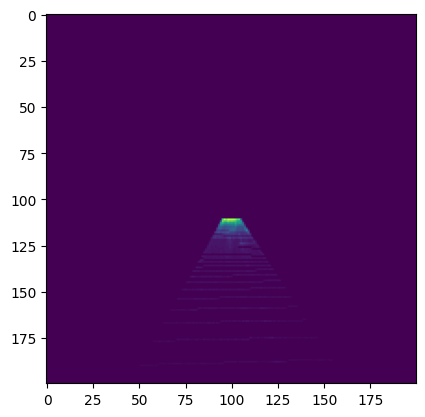

In [ ]:
bev = torch.load("/home/draiman/Desktop/debug_/raw_cam_bev.pt")

plt.imshow(bev.norm(dim=0))


In [35]:

import os
import glob
import csv
import ast
import torch
import torch.nn.functional as F
from torch.utils.data import ConcatDataset
import numpy as np
from lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov


# ============================================================
# BEV spec
# ============================================================

class BEVSpec:
    """
    Defines the canonical BEV grid for fusion.
    """
    def __init__(self, x_min=0.0, x_max=50.0, cell_x=0.4,
                 y_min=-25.0, y_max=25.0, cell_y=0.25):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))


# ============================================================
# Calibration handling (from calib_trainval_front.csv)
# ============================================================

class CameraCalib:
    """
    Holds per-sample camera & LiDAR calibration.
    """
    def __init__(self, K, R, T, lidar2img, img_shape):
        self.K = K          # 3x3
        self.R = R          # 3x3, cam->ego
        self.T = T          # (3,)
        self.lidar2img = lidar2img  # 3x4
        self.img_shape = img_shape  # (H, W)


def load_calib_db(csv_file, cam_channel="CAM_FRONT"):
    """
    Build a dict:
        (sample_token, cam_channel) -> CameraCalib

    Same parsing semantics as your Jupyter load_calib_from_csv.
    """
    calib_db = {}
    with open(csv_file, mode='r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            token = row["sample_token"]
            ch = row["cam_channel"]
            # Only keep the camera channel we care about (e.g., CAM_FRONT)
            if ch != cam_channel:
                continue

            K = np.array(ast.literal_eval(row["K_flat"]), dtype=np.float64).reshape(3, 3)
            R = np.array(ast.literal_eval(row["R_flat"]), dtype=np.float64).reshape(3, 3)
            T = np.array(ast.literal_eval(row["T_flat"]), dtype=np.float64).reshape(3,)
            lidar2img = np.array(ast.literal_eval(row["lidar2img_flat"]),
                                 dtype=np.float64).reshape(3, 4)
            img_shape = (int(row["img_height"]), int(row["img_width"]))
            calib_db[(token, ch)] = CameraCalib(K=K, R=R, T=T,
                                                lidar2img=lidar2img,
                                                img_shape=img_shape)
    return calib_db


# ============================================================
# Token matching from camera & lidar dirs
# ============================================================

def get_matched_tokens(camera_feat_root, lidar_root, fpn_level):
    """
    Match tokens based on filenames:
      camera: {token}_lvl{fpn}.pt
      lidar:  {token}.pt
    """
    cam_files = glob.glob(os.path.join(camera_feat_root, f"*lvl{fpn_level}.pt"))
    lidar_files = glob.glob(os.path.join(lidar_root, "*.pt"))

    cam_tokens = {
        os.path.basename(f).replace(f"_lvl{fpn_level}.pt", ""): f
        for f in cam_files
    }
    lidar_tokens = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in lidar_files
    }

    matched = sorted(set(cam_tokens.keys()) & set(lidar_tokens.keys()))
    return matched


# ============================================================
# Camera BEV dataset (uses K,R,T,img_shape from calib CSV)
# ============================================================

class TorchCameraBEVDataset:
    """
    Loads and projects FPN camera features into BEV grid using
    explicit calibration (K, R, T) from calib_trainval_front.csv.
    """
    def __init__(self,
                 sample_tokens,
                 camera_feat_root: str,
                 camera_name: str,
                 fpn_level: int,
                 bev_spec: BEVSpec,
                 calib_db: dict):
        self.sample_tokens = sample_tokens
        self.camera_feat_root = camera_feat_root
        self.camera_name = camera_name
        self.fpn_level = fpn_level
        self.bev_spec = bev_spec
        self.calib_db = calib_db

    def __len__(self):
        return len(self.sample_tokens)

    def _lookup_calib(self, token: str) -> CameraCalib:
        key = (token, self.camera_name)
        if key not in self.calib_db:
            raise KeyError(f"Calibration not found for token={token}, cam={self.camera_name}")
        return self.calib_db[key]

    def _load_camera_feat(self, token: str, calib: CameraCalib):
        """
        Load camera FPN feature and compute stride using image shape.
        """
        feat_filename = f"{token}_lvl{self.fpn_level}.pt"
        feat_path = os.path.join(self.camera_feat_root, feat_filename)
        blob = torch.load(feat_path, map_location="cpu")
        cam_feat = blob["feat"]   # [1,C,Hf,Wf] or [C,Hf,Wf]

        if cam_feat.ndim == 3:
            cam_feat = cam_feat.unsqueeze(0)  # [1,C,Hf,Wf]

        Hf, Wf = cam_feat.shape[-2], cam_feat.shape[-1]
        H_img, W_img = calib.img_shape

        # Your Jupyter code did: stride = img_shape[0] // Hf
        # Use float stride for more precision; it's equivalent if divisible.
        stride = H_img / Hf  # assuming same aspect ratio

        self._stride = stride
        self._img_shape = (H_img, W_img)
        return cam_feat

    def __getitem__(self, idx):
        token = self.sample_tokens[idx]
        calib = self._lookup_calib(token)
        cam_feat = self._load_camera_feat(token, calib)  # [1,C,Hf,Wf]
        B, C, Hf, Wf = cam_feat.shape
        stride = self._stride

        # ---- Compute pixel centers (like in your Jupyter code) ----
        i = torch.arange(Hf, dtype=torch.float32) + 0.5
        j = torch.arange(Wf, dtype=torch.float32) + 0.5
        V, U = torch.meshgrid(i * stride, j * stride, indexing='ij')  # [Hf,Wf]

        U = U.numpy()
        V = V.numpy()

        # ---- Backproject rays → camera → ego ----
        K = calib.K
        R_cam2ego = calib.R
        T_cam2ego = calib.T

        K_inv = np.linalg.inv(K)
        uv1 = np.stack([U.reshape(-1), V.reshape(-1), np.ones(Hf * Wf)], axis=0)
        rays_cam = K_inv @ uv1
        rays_cam[1, :] *= -1.0  # flip y (same as your Jupyter code)

        rays_ego = R_cam2ego @ rays_cam
        C_ego = T_cam2ego.reshape(3)

        cam_z = C_ego[2]
        dir_z = rays_ego[2, :]
        s = -cam_z / (dir_z + 1e-12)  # intersection with ground plane z=0
        valid = s > 0

        X = C_ego[0] + s * rays_ego[0, :]
        Y = C_ego[1] + s * rays_ego[1, :]

        # ---- Define canonical BEV grid (same as your Jupyter) ----
        x_min, x_max = self.bev_spec.x_min, self.bev_spec.x_max
        y_min, y_max = self.bev_spec.y_min, self.bev_spec.y_max
        cell_x, cell_y = self.bev_spec.cell_x, self.bev_spec.cell_y
        H_bev, W_bev = self.bev_spec.H, self.bev_spec.W

        bev = torch.zeros((C, H_bev, W_bev), dtype=cam_feat.dtype)

        ix = ((X - x_min) / cell_x).astype(np.int64)
        iy = ((Y - y_min) / cell_y).astype(np.int64)
        inside = valid & (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev)

        feat_flat = cam_feat.reshape(C, -1)  # [C, Hf*Wf]
        idxs = np.where(inside)[0]
        for n in idxs:
            bev[:, ix[n], iy[n]] += feat_flat[:, n]


        print("CAM FEATURE SHAPE:", cam_feat.shape, 
        "from", os.path.join(self.camera_feat_root, f"{token}_lvl{self.fpn_level}.pt"))
        if idx == 0:
            torch.save(bev.cpu(), "/home/draiman/Desktop/debug_/raw_cam_bev_main.pt")

        # [C,H_bev,W_bev]
        return {
            "cam_bev": bev,
            "image_id": token,
        }

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
        image_ids = [s["image_id"] for s in samples]
        
        
        # # if random.random() < 0.01:   # occasionally debug
        # raw = cam_bev_batch[0].cpu()
        # torch.save(raw, "/home/draiman/Desktop/debug_recons_2/raw_cam_bev.pt")

        
        return {
            "cam_bev": cam_bev_batch,
            "image_id": image_ids,
        }


# ============================================================
# LiDAR BEV dataset (uses lidar2img + FOV masking + grid_sample)
# ============================================================

class TorchLidarBEVDataset:
    """
    Loads LiDAR BEV features, masks them to the camera FOV using lidar2img,
    then resamples to the canonical BEV grid.
    """
    def __init__(self,
                 sample_tokens,
                 lidar_root: str,
                 pc_range,
                 bev_spec: BEVSpec,
                 calib_db: dict,
                 camera_name: str):
        self.sample_tokens = sample_tokens
        self.lidar_root = lidar_root
        self.pc_range = pc_range  # e.g., [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
        self.bev_spec = bev_spec
        self.calib_db = calib_db
        self.camera_name = camera_name

    def __len__(self):
        return len(self.sample_tokens)

    def _lookup_calib(self, token: str) -> CameraCalib:
        key = (token, self.camera_name)
        if key not in self.calib_db:
            raise KeyError(f"Calibration not found for token={token}, cam={self.camera_name}")
        return self.calib_db[key]

    def _load_lidar_feat(self, token: str):
        """
        Load LiDAR BEV tensor for a token.
        You used blob['spatial'].squeeze(0) in your notebook.
        """
        feat_path = os.path.join(self.lidar_root, f"{token}.pt")
        blob = torch.load(feat_path, map_location="cpu")

        if "spatial" in blob:
            lidar_feat = blob["spatial"]
        # if "bev_c1" in blob:
        #     lidar_feat = blob["bev_c1"]

        else:
            # fallback if stored as "feat"
            lidar_feat = blob["feat"]
            # lidar_feat = blob["spatial"]

        if lidar_feat.ndim == 3:
            lidar_feat = lidar_feat.unsqueeze(0)  # [1, C, H_raw, W_raw]

        return lidar_feat

    def __getitem__(self, idx):
        token = self.sample_tokens[idx]
        calib = self._lookup_calib(token)
        lidar_feat = self._load_lidar_feat(token)  # [1, C, H_raw, W_raw]
        B, C, H_raw, W_raw = lidar_feat.shape
        assert B == 1, "Expected LiDAR feat with batch dim 1."

        lidar_bev = lidar_feat.squeeze(0)  # [C, H_raw, W_raw]

        x_min_l, y_min_l, _, x_max_l, y_max_l, _ = self.pc_range

        # ---- Compute BEV resolution from pc_range & raw shape ----
        # (You used bev_resolution=(0.57,0.57) in the notebook; here we compute it generically.)
        bev_res_x = (x_max_l - x_min_l) / H_raw
        bev_res_y = (y_max_l - y_min_l) / W_raw
        bev_resolution = (bev_res_x, bev_res_y)

        # ---- FOV masking using lidar2img + img_shape ----
        lidar2img = calib.lidar2img
        img_shape = calib.img_shape  # (H_img, W_img)

        masked_lidar = crop_lidar_bev_to_camera_fov(
            lidar_bev,            # [C, H_raw, W_raw]
            lidar2img,            # 3x4 numpy array
            img_shape,            # (H, W)
            bev_resolution=bev_resolution,
            pc_range=self.pc_range,
        )  # [C, H_raw, W_raw] masked to camera FOV
        
        # masked_lidar = lidar_bev # no masking for testing

        # ---- Resample masked LiDAR into canonical BEV grid via grid_sample ----
        masked_lidar_batch = masked_lidar.unsqueeze(0)  # [1, C, H_raw, W_raw]

        H_cam = self.bev_spec.H
        W_cam = self.bev_spec.W
        cell_x = (self.bev_spec.x_max - self.bev_spec.x_min) / H_cam
        cell_y = (self.bev_spec.y_max - self.bev_spec.y_min) / W_cam

        xs = self.bev_spec.x_min + (torch.arange(H_cam, dtype=torch.float32) + 0.5) * cell_x
        ys = self.bev_spec.y_min + (torch.arange(W_cam, dtype=torch.float32) + 0.5) * cell_y
        Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

        grid_x = 2.0 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1.0
        grid_y = 2.0 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1.0
        grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)  # [1, H_cam, W_cam, 2]

        lidar_bev_canonical = F.grid_sample(
            masked_lidar_batch,
            grid,
            mode='bilinear',
            padding_mode='zeros',
            align_corners=True
        ).squeeze(0)  # [C, H_cam, W_cam]

        return {
            "lidar_bev": lidar_bev_canonical,
            "image_id": token,
        }


# ============================================================
# Wrapper dataset to return (cam_bev, lidar_bev) pairs
# ============================================================

class WrappedConcatBEVDataset(ConcatDataset):
    """
    Returns paired (camera, lidar) BEV tensors for each token.
    """
    def __init__(self,
                 cam_dataset: TorchCameraBEVDataset,
                 lidar_dataset: TorchLidarBEVDataset):
        assert len(cam_dataset) == len(lidar_dataset), \
            "Camera and LiDAR token sets must align 1:1."
        super().__init__([cam_dataset, lidar_dataset])
        self.cam_dataset = cam_dataset
        self.lidar_dataset = lidar_dataset

    def __len__(self):
        return min(len(self.cam_dataset), len(self.lidar_dataset))

    def __getitem__(self, idx):
        cam_sample = self.cam_dataset[idx]
        lidar_sample = self.lidar_dataset[idx]
        if cam_sample is None or lidar_sample is None:
            return None
        if cam_sample["image_id"] != lidar_sample["image_id"]:
            return None
        return {
            "cam_bev": cam_sample["cam_bev"],
            "lidar_bev": lidar_sample["lidar_bev"],
            "image_id": cam_sample["image_id"],
            "label": 1,
        }

    def collater(self, samples):
        samples = [s for s in samples if s is not None]
        if len(samples) == 0:
            return {}
        cam_bev_batch = torch.stack([s["cam_bev"] for s in samples])
        lidar_bev_batch = torch.stack([s["lidar_bev"] for s in samples])
        image_ids = [s["image_id"] for s in samples]
        labels = torch.tensor([s["label"] for s in samples])
        return {
            "cam_bev": cam_bev_batch,
            "lidar_bev": lidar_bev_batch,
            "image_id": image_ids,
            "label": labels,
        }

class NuScenesDatasetBuilder:
    def __init__(self, cfg):
        self.cfg = cfg

    def build_datasets(self):
        build_info = self.cfg.datasets_cfg["nuscenes"].build_info
        datasets = {}

        for split in ["train", "val", "test"]:
            # Only build if split in run config
            if split not in (self.cfg.run_cfg.train_splits + 
                             self.cfg.run_cfg.valid_splits +
                             self.cfg.run_cfg.test_splits):
                continue

            camera_root = build_info["camera"][split].storage
            lidar_root = build_info["lidar"][split].storage
            calib_csv = build_info.get("calib_csv", 
                         "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/final_resources/calib_trainval_front.csv")
            camera_name = build_info["cam_proj"].camera_name
            fpn_level = build_info["cam_proj"].fpn_level
            pc_range = build_info["lidar_proj"].pc_range

            bev_cfg = build_info["bev"]
            bev_spec = BEVSpec(
                x_min=bev_cfg.x_min, x_max=bev_cfg.x_max, cell_x=bev_cfg.cell_x,
                y_min=bev_cfg.y_min, y_max=bev_cfg.y_max, cell_y=bev_cfg.cell_y,
            )

            calib_db = load_calib_db(calib_csv, cam_channel=camera_name)
            tokens = get_matched_tokens(camera_root, lidar_root, fpn_level)

            cam_ds = TorchCameraBEVDataset(
                sample_tokens=tokens,
                camera_feat_root=camera_root,
                camera_name=camera_name,
                fpn_level=fpn_level,
                bev_spec=bev_spec,
                calib_db=calib_db,
            )
            lidar_ds = TorchLidarBEVDataset(
                sample_tokens=tokens,
                lidar_root=lidar_root,
                pc_range=pc_range,
                bev_spec=bev_spec,
                calib_db=calib_db,
                camera_name=camera_name,
            )
            datasets[split] = WrappedConcatBEVDataset(cam_ds, lidar_ds)

        return datasets

# ============================================================
# main(): same style as your simple example
# ============================================================
def main():
    # ---- Paths (you can change these later) ----
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT"  # where {token}_lvl0.pt live
    lidar_dir = "/data/nusc_lidar/train"    # where {token}.pt live
    calib_csv = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/final_resources/calib_trainval_front.csv"

    camera_name = "CAM_FRONT"
    fpn_level = 0
    pc_range = [-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]

    bev_spec = BEVSpec(
        x_min=0.0, x_max=50.0, cell_x=0.4,
        y_min=-25.0, y_max=25.0, cell_y=0.25,
    )

    # ---- Load calibration DB once ----
    calib_db = load_calib_db(calib_csv, cam_channel=camera_name)
    print(f"Loaded {len(calib_db)} calibration entries for {camera_name}.")

    # ---- Match tokens from camera + lidar dirs ----
    tokens = get_matched_tokens(camera_dir, lidar_dir, fpn_level=fpn_level)
    print(f"Found {len(tokens)} matched tokens.")

    # ---- Instantiate datasets ----
    cam_ds = TorchCameraBEVDataset(
        sample_tokens=tokens,
        camera_feat_root=camera_dir,
        camera_name=camera_name,
        fpn_level=fpn_level,
        bev_spec=bev_spec,
        calib_db=calib_db,
    )

    lidar_ds = TorchLidarBEVDataset(
        sample_tokens=tokens,
        lidar_root=lidar_dir,
        pc_range=pc_range,
        bev_spec=bev_spec,
        calib_db=calib_db,
        camera_name=camera_name,
    )

    dataset = WrappedConcatBEVDataset(cam_ds, lidar_ds)

    # ---- Inspect a few samples ----
    for i in range(min(3, len(dataset))):
        sample = dataset[i]
        if sample is None:
            continue
        print(f"\nSample {i}:")
        print(f"Camera BEV shape: {tuple(sample['cam_bev'].shape)}")
        print(f"LiDAR  BEV shape: {tuple(sample['lidar_bev'].shape)}")
        print(f"Token/Image ID:  {sample['image_id']}")
        print(f"Label:           {sample['label']}")


        
        print("CAM FEATURE SHAPE:", sample['cam_bev'].shape, "from", os.path.join(camera_dir, f"{tokens}_lvl{0}.pt"))

    return dataset  
if __name__ == "__main__":
    dataset = main()


Loaded 34149 calibration entries for CAM_FRONT.
Found 11547 matched tokens.
CAM FEATURE SHAPE: torch.Size([1, 256, 116, 200]) from /home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/00014584c6de4789a69b4717fa3c0d22_lvl0.pt

Sample 0:
Camera BEV shape: (256, 125, 200)
LiDAR  BEV shape: (256, 125, 200)
Token/Image ID:  00014584c6de4789a69b4717fa3c0d22
Label:           1
CAM FEATURE SHAPE: torch.Size([256, 125, 200]) from /home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/['00014584c6de4789a69b4717fa3c0d22', '000bc348ae6541abac85e51b266039b5', '000cf4dfaab54d21a7314036fde74966', '001064bb06504334862b65e6252d4eb9', '001899e5cdf548fba1e27741e0d172a5', '001d63f61c024f8bb791acbfa4628249', '001e8f543f6c42309bcce1f4ee6cbfa5', '002797644545490a861b0dfd5518f8be', '0029328f0ec34627a18db7b7f27b462e', '0029daa238304e1d8352a84d0eb976bc', '002e29737f254cfba8914a87611a3699', '0032005d81f04d109c67ae92af4d0a2f', '00321788e22a47d6aa355795a1a05d5a', '0036750ff63145b1ab611faecbab12f5', '00

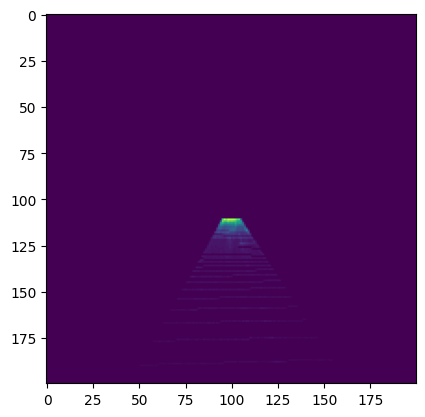

In [ ]:
bev = torch.load("/home/draiman/Desktop/debug_/raw_cam_bev.pt")
plt.imshow(bev.norm(dim=0))

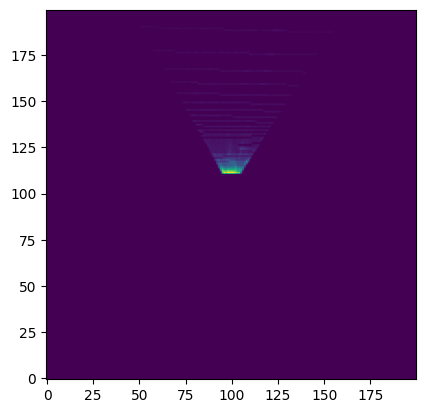

In [51]:
bev = torch.load("/home/draiman/Desktop/debug_/raw_cam_bev.pt")
plt.imshow(bev.norm(dim=0), origin="lower")




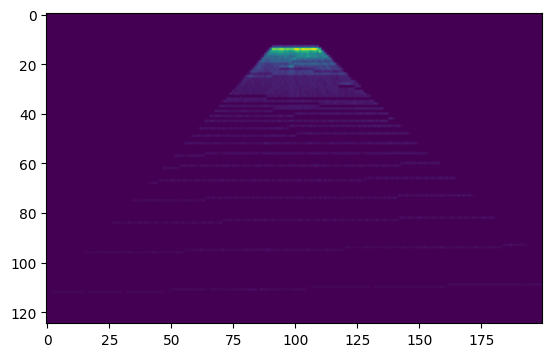

In [ ]:
bev_main = torch.load("/home/draiman/Desktop/debug_/raw_cam_bev_main.pt")
plt.imshow(bev_main.norm(dim=0))

